# Paired biopsy–resection proteomics analysis


This notebook analyzes DIA-NN gene-level MaxLFQ intensities for paired biopsy
and resection samples from non-tumor liver and HCC. It performs sample matching,
quality control, log2 transformation, within-condition KNN imputation, a paired
t-test workflow, a non-imputed paired limma sensitivity analysis, PCA and
patient-blocked permutation testing, pathway enrichment, and result export.

**Primary inputs**

- `diann_report_new.parquet`: DIA-NN report containing run, protein, gene, and
  `Genes.MaxLFQ` fields.
- `../sample_mapping_BvR.csv`: patient/sample mapping and clinical covariates.

**Cohort decisions retained from the original analysis**

- Only HCC cases with all four proteomics samples are eligible.
- Patients F, C, P, U, and J are excluded for documented PCA, interval, or
  identification-count reasons.
- Zero/absent measurements are treated as missing before log2 transformation.
- KNN imputation uses three neighbors and is fitted separately within biopsy and
  resection samples; limma is also run on non-imputed values as a sensitivity analysis.


## 1. Environment and imports

Load data-processing, plotting, enrichment, imputation, PCA, and limma dependencies.

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import seaborn as sns
import re
from pprint import pprint
from scipy import stats
from functools import reduce
#import dash_bio
import pyarrow
import math
from scipy.stats import linregress
from scipy.stats import pearsonr, spearmanr
from scipy.spatial.distance import pdist
from scipy.stats import percentileofscore

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer

import itertools

from importlib.metadata import version

from patsy import dmatrix, Treatment


from inmoose.limma import lmFit, eBayes, topTable

import csv

#from gseapy.plot import barplot, dotplot
import gseapy as gp
from gseapy import Msigdb

from tqdm import tqdm

from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')

%matplotlib inline
pd.set_option('display.max_columns', None)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

## 2. Load and reshape DIA-NN output

Read the parquet report, retain the required fields, remove invalid rows, pivot runs to columns, and aggregate identical gene identifiers.

In [121]:
# Change the file name below to your input file name
input_file_name = 'diann_report_new.parquet'


In [122]:
df = pd.read_parquet(input_file_name)
df = df.loc[:,['Run', 'Protein.Ids', 'Genes', 'Genes.MaxLFQ']]
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
0,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,764408.125
1,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,2928613.250
2,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,1817925.250
3,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,979622.250
4,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P55011,SLC12A2,2423264.000


In [123]:
df = df.sort_values('Genes')
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
887581,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P01871;P0DOX6,,0.0
1228386,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
1228385,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
1228384,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0
1228383,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,,,0.0


In [124]:
df = df[df['Protein.Ids'] != '']
df = df[df['Genes.MaxLFQ'] > 0]
df.head()

,Run,Protein.Ids,Genes,Genes.MaxLFQ
2615064,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,9348254.0
2615065,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,24382746.0
2220079,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,12572289.0
2220080,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,7227491.5
2220081,/scicore/home/heimm/GROUP/Fredrik/projects/Mar...,P04217,A1BG,12279504.0


In [125]:
df_p = df.pivot_table(columns='Run', index=['Genes', 'Protein.Ids'], values='Genes.MaxLFQ')
df_p.columns = df_p.columns.str.split('/').str[-1].str.split('.').str[0]
#df_p.index = df_p.index.droplevel(0)
df_p = df_p.reset_index()
df_p = df_p.drop('Protein.Ids', axis=1)

# Identical intensity values for rows with same gene ids
df_p = df_p.groupby('Genes').mean()
df_p.head()

Run,001_BR-LF-3_C21,002_BR-LF-3_C21,003_BR-LF-3_C21,004_BR-LF-3_C21,005_BR-LF-3_C21,006_BR-LF-3_C21,007_BR-LF-3_C21,009_BR-LF-3_C21,010_BR-LF-3_C21,011_BR-LF-3_C21,012_BR-LF-3_C21,013_BR-LF-3_C21,014_BR-LF-3_C21,015_BR-LF-3_C21,016_BR-LF-3_C21,017_BR-LF-3_C21,018_BR-LF-3_C21,019_BR-LF-3_C21,020_BR-LF-3_C21,021_BR-LF-3_C21,022_BR-LF-3_C21,023_BR-LF-3_C21,024_BR-LF-3_C21,025_BR-LF-3_C21,026_BR-LF-3_C21,027_BR-LF-3_C21,028_BR-LF-3_C21,029_BR-LF-3_C21,030_BR-LF-3_C21,031_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,034_BR-LF-3_C21,035_BR-LF-3_C21,036_BR-LF-3_C21,037_BR-LF-3_C21,038_BR-LF-3_C21,039_BR-LF-3_C21,040_BR-LF-3_C21,041_BR-LF-3_C21,042rr_BR-LF-3_C21,043r_BR-LF-3_C21,044r_BR-LF-3_C21,045_BR-LF-3_C21,046_BR-LF-3_C21,047_BR-LF-3_C21,048_BR-LF-3_C21,049_BR-LF-3_C21,050_BR-LF-3_C21,051_BR-LF-3_C21,052_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,055_BR-LF-3_C21,056_BR-LF-3_C21,057_BR-LF-3_C21,058_BR-LF-3_C21,059_BR-LF-3_C21,060_BR-LF-3_C21,061_BR-LF-3_C21,062_BR-LF-3_C21,063_BR-LF-3_C21,064_BR-LF-3_C21,065_BR-LF-3_C21,066_BR-LF-3_C21,067_BR-LF-3_C21,068_BR-LF-3_C21,069_BR-LF-3_C21,070_BR-LF-3_C21,071_BR-LF-3_C21,072_BR-LF-3_C21,075_BR-LF-3_C21,076_BR-LF-3_C21,077_BR-LF-3_C21,078_BR-LF-3_C21,079_BR-LF-3_C21,080_BR-LF-3_C21,081_BR-LF-3_C21,082_BR-LF-3_C21,083_BR-LF-3_C21,084_BR-LF-3_C21,085_BR-LF-3_C21,086_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,1.390318e+07,8.092702e+06,9.093792e+06,9.829568e+06,63904276.0,11431095.00,1.209570e+07,12919463.00,1.560926e+07,1.257229e+07,1.001231e+07,6.774724e+06,5.360522e+06,6.963499e+06,8.372235e+06,1.841911e+07,1.172495e+07,102929224.0,1.363062e+07,1.244640e+07,1.443611e+07,9.381553e+06,9.821265e+06,1.709066e+07,1.382630e+07,6.623556e+06,1.171417e+07,4861199.50,8094040.0,1.484680e+07,9.516583e+06,8.201244e+06,1.297275e+07,4.883674e+06,1.735225e+07,1.955086e+07,2.650290e+06,2.438275e+07,1.227950e+07,9.348254e+06,3.610431e+06,1.095610e+07,35999560.00,1.240873e+07,1.325866e+07,9170218.0,5.169790e+06,1.144538e+07,8.279908e+06,1.149052e+07,2.782788e+06,7.285012e+06,5.625501e+06,9.259266e+06,17319670.00,14688824.0,3.333154e+06,8.028981e+06,1.226772e+07,126250248.0,9.576698e+06,1.062272e+07,1.458237e+07,4.733590e+06,1.575535e+07,3.534760e+07,7.788006e+06,4.516871e+06,9.570544e+06,1.368729e+07,1.283754e+07,1.299908e+07,5.059194e+06,6097338.0,1.060194e+07,8.449616e+06,9.202670e+06,4.600116e+06,33868632.0,8.926515e+06,7.221492e+06,7.227491e+06,1.490669e+07,6.284920e+06,2.779270e+06,6.180944e+06,7.864388e+06
A1CF,7.310880e+06,5.502881e+06,7.058914e+06,9.554567e+06,NaN,9851524.00,1.183754e+06,7013576.00,6.799258e+06,8.870349e+06,6.573526e+06,1.134740e+07,4.049204e+06,8.697785e+06,8.458427e+06,7.540301e+06,9.194561e+06,3814954.0,7.980846e+06,4.808228e+06,8.273442e+06,6.209378e+06,8.142430e+06,6.030916e+06,9.330567e+06,1.041517e+07,9.277235e+06,5981235.00,8184606.0,1.256131e+06,9.494816e+06,6.256870e+06,1.014718e+07,5.141198e+06,1.646420e+06,8.424932e+06,5.235777e+05,1.236329e+07,5.177204e+06,8.759055e+06,5.549406e+06,7.350624e+06,7493298.00,7.615296e+06,8.853148e+06,11567957.0,5.107336e+06,9.180874e+06,5.446120e+06,1.081143e+07,8.690221e+06,9.642759e+06,6.750974e+06,1.139895e+07,1258216.25,9740235.0,3.791771e+06,8.688081e+06,3.435663e+06,2476497.0,1.090786e+06,8.430888e+06,1.375989e+06,1.008872e+06,1.985253e+06,1.126004e+06,8.897156e+06,3.324285e+06,1.177438e+07,5.630188e+06,9.971907e+06,9.015822e+06,4.121094e+06,9418328.0,8.907513e+06,9.601550e+06,1.192995e+07,2.689324e+06,16146531.0,1.308169e+07,5.267596e+06,8.369406e+06,4.467737e+06,1.014299e+07,5.718725e+06,1.031440e+07,8.691277e+06
A2M,4.741191e+07,3.539994e+07,3.718071e+07,1.905792e+07,162658512.0,12088493.00,1.348582e+07,31376376.00,2.947411e+07,4.229280e+07,1.849556e+07,1.779512e+07,2.040225e+07,7.744451e+06,8.411916e+06,2.282820e+07,2.311840e+07,103304608.0,8.092730e+07,9.544926e+07,7.178288e+07,4.680340e+07,2.156725e

In [126]:
df_p.shape

(8069, 87)

## 3. Select and verify mapped samples

Load the mapping, apply the documented patient exclusions, report missing/extra runs, and retain only the analysis samples.

In [127]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
prot_cols = ['Biopsy_nt_proteome', 'Biopsy_tu_proteome',
             'Resection_nt_protome', 'Resection_tu_protome']
meta = meta.dropna(subset=prot_cols)

# Remove smaple with large time beteen biopsy and resection
meta = meta[meta['Patient ID'] != 'C']

# Additional sample outliers in HCC dataset, samples with low amount of identifications
meta = meta[~meta['Patient ID'].isin(['P','U','J','F'])]

meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
17,I,BSSE_QGF_182072,BSSE_QGF_182073,BSSE_QGF_182106,BSSE_QGF_182107,024_BR-LF-3_C21,025_BR-LF-3_C21,053_BR-LF-3_C21,054_BR-LF-3_C21,024_BR-LF-3P_PO4_C21,025_BR-LF-3P_PO4_C21,053_BR-LF-3P_PO4_C21,054_BR-LF-3P_PO4_C21,54.0,F,6.0,35.0,34.0,53.0,92.0,39.0,5.0,91.0,148.0,8.0,142.0,2.0,4.0,6.0,37.0,33.0,44.0,79.0,36.0,6.0,91.0,129.0,6.0,140.0,1.2,NaN,A,A,1,55.0,30.0,157.0,HCC,84.0,94.0,16.0,6.0,75.0,99.0,17.0,1.0,0.0,0.0,8.0,0.0
23,L,BSSE_QGF_145460,BSSE_QGF_145461,BSSE_QGF_145462,BSSE_QGF_145463,071_BR-LF-3_C21,072_BR-LF-3_C21,084_BR-LF-3_C21,085_BR-LF-3_C21,071r_BR-LF-3P_PO4_C21,072r_BR-LF-3P_PO4_C21,084_BR-LF-3P_PO4_C21,085_BR-LF-3P_PO4_C21,66.0,F,8.0,14.0,28.0,86.0,63.0,20.0,14.0,70.0,115.0,8.0,90.0,21.0,NaN,8.0,15.0,26.0,68.0,73.0,29.0,14.0,75.0,140.0,8.0,111.0,22.0,NaN,A,A,1,28.0,18.0,67.0,HCC,47.0,74.0,53.0,26.0,96.0,91.0,4.0,9.0,0.0,0.0,0.0,0.0
27,N,BSSE_QGF_182054,BSSE_QGF_182055,BSSE_QGF_182084,BSSE_QGF_182085,013_BR-LF-3_C21,014_BR-LF-3_C21,034_BR-LF-3_C21,035_BR-LF-3_C21,013_BR-LF-3P_PO4_C21,014_BR-LF-3P_PO4_C21,034_BR-LF-3P_PO4_C21,035_BR-LF-3P_PO4_C21,60.0,M,6.0,12.0,24.0,33.0,99.0,42.0,3.0,0.0,137.0,6.0,220.0,0.6,NaN,6.0,18.0,29.0,202.0,163.0,44.0,7.0,93.0,148.0,13.0,302.0,3.0,NaN,NaN,A,2,15.0,15.0,108.0,HCC,96.0,74.0,4.0,26.0,64.0,50.0,24.0,50.0,12.0,0.0,0.0,0.0


In [128]:
# Check if we have all proteome samples in the spectronout output
found = []
for group in prot_cols:
    for seq_id in meta[group]:
        if seq_id in df_p.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)

In [129]:
# Extras
extras = []
for seq_id in df_p.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
df_ = df_p.drop(extras, axis=1)

extra: 001_BR-LF-3_C21
extra: 002_BR-LF-3_C21
extra: 003_BR-LF-3_C21
extra: 004_BR-LF-3_C21
extra: 005_BR-LF-3_C21
extra: 006_BR-LF-3_C21
extra: 007_BR-LF-3_C21
extra: 009_BR-LF-3_C21
extra: 010_BR-LF-3_C21
extra: 015_BR-LF-3_C21
extra: 016_BR-LF-3_C21
extra: 017_BR-LF-3_C21
extra: 018_BR-LF-3_C21
extra: 019_BR-LF-3_C21
extra: 028_BR-LF-3_C21
extra: 029_BR-LF-3_C21
extra: 030_BR-LF-3_C21
extra: 031_BR-LF-3_C21
extra: 036_BR-LF-3_C21
extra: 037_BR-LF-3_C21
extra: 038_BR-LF-3_C21
extra: 039_BR-LF-3_C21
extra: 040_BR-LF-3_C21
extra: 041_BR-LF-3_C21
extra: 042rr_BR-LF-3_C21
extra: 043r_BR-LF-3_C21
extra: 044r_BR-LF-3_C21
extra: 045_BR-LF-3_C21
extra: 046_BR-LF-3_C21
extra: 055_BR-LF-3_C21
extra: 056_BR-LF-3_C21
extra: 057_BR-LF-3_C21
extra: 058_BR-LF-3_C21
extra: 059_BR-LF-3_C21
extra: 060_BR-LF-3_C21
extra: 061_BR-LF-3_C21
extra: 062_BR-LF-3_C21
extra: 063_BR-LF-3_C21
extra: 064_BR-LF-3_C21
extra: 065_BR-LF-3_C21
extra: 066_BR-LF-3_C21
extra: 067_BR-LF-3_C21
extra: 068_BR-LF-3_C21
extra: 

## 4. Build sample-level metadata

Reshape proteomics identifiers and tissue-composition fields into one row per sample and assign readable column labels.

In [130]:
# tissue composition cols
tissue_comp_cols = ["Biopsy_nt_hepatocyte", "Resection_nt_hepatocyte", "Biopsy_nt_stroma",
                     "Resection_nt_stroma", "Biopsy_tu_tumor", "Resection_tu_tumor", "Biopsy_tu_stroma",
                     "Resection_tu_stroma", "Biopsy_tu_necrosis", "Resection_tu_necrosis", "Biopsy_tu_nontumor",
                     "Resection_tu_nontumor"]

meta_prot = meta.loc[:,['Patient ID', 'Biopsy_nt_proteome', 'Biopsy_tu_proteome',
                        'Resection_nt_protome', 'Resection_tu_protome',
                        'Age', 'Sex','Time between resection and biopsy',
                        'Total surgery time = ischemia time'] + tissue_comp_cols].copy()
meta_prot_ = meta_prot.melt(id_vars=['Patient ID', 'Age', 'Sex',
                                  'Time between resection and biopsy',
                                  'Total surgery time = ischemia time'],
                         value_vars=prot_cols)

meta_prot_tissue = meta_prot.melt(id_vars=['Patient ID'],
                         value_vars=tissue_comp_cols)
meta_prot_tissue['Sample_type'] = meta_prot_tissue.variable.str.split('_').str[0]
meta_prot_tissue['Tissue'] = np.where(meta_prot_tissue.variable.str.contains('_nt_'),
                                      'non-tumor', 'tumor')
meta_prot_tissue = meta_prot_tissue[meta_prot_tissue.Tissue == 'tumor']

meta_prot_['Sample_type'] = meta_prot_.variable.str.split('_').str[0]
meta_prot_['Tissue'] = np.where(meta_prot_.variable.str.contains('nt'), 'non-tumor', 'tumor')
meta_prot_ = meta_prot_.drop('variable', axis=1)
meta_prot_ = meta_prot_.rename({'value':'Seq_id', 'Total surgery time = ischemia time': 'Total surgery time',
                           'Patient ID': 'patient_id'}, axis=1)

# biopsy dont have surgery time
meta_prot_['Total surgery time'] = np.where(meta_prot_['Sample_type'] == 'Biopsy', 0,
                                           meta_prot_['Total surgery time'])

# Make new column with column names
meta_prot_['col_names'] = meta_prot_.Tissue.str\
                            .cat(meta_prot_.Sample_type.str\
                                .cat(meta_prot_.patient_id, sep='_'), sep='_')
meta_prot_.index = meta_prot_.Seq_id
meta_prot_ = meta_prot_.sort_index()

meta_prot_.patient_id.unique()

array(['D', 'N', 'O', 'Q', 'I', 'T', 'L', 'E'], dtype=object)

In [131]:
meta_prot_tissue['variable'] = meta_prot_tissue['variable'].str.split('_').str[-1]

meta_prot_tissue_p = meta_prot_tissue.pivot(columns='variable',
                                        index=['Patient ID', 'Sample_type'],
                                        values='value')
meta_prot_tissue_p['total'] = meta_prot_tissue_p.sum(axis=1)

meta_prot_tissue_p = meta_prot_tissue_p.reset_index()
meta_prot_tissue_p.index = meta_prot_tissue_p['Patient ID'] + '_' + meta_prot_tissue_p['Sample_type']
meta_prot_tissue_p = meta_prot_tissue_p.drop('Sample_type', axis=1)
meta_prot_tissue_p.head()

variable,Patient ID,necrosis,nontumor,stroma,tumor,total
D_Biopsy,D,0.0,24.0,29.0,47.0,100.0
D_Resection,D,0.0,0.0,3.0,97.0,100.0
E_Biopsy,E,5.0,15.0,19.0,61.0,100.0
E_Resection,E,0.0,0.0,1.0,99.0,100.0
I_Biopsy,I,0.0,8.0,17.0,75.0,100.0


In [132]:
meta_prot_v = meta_prot_.copy()
meta_prot_v.index = meta_prot_v['patient_id'] + '_' + meta_prot_v['Sample_type']
meta_prot = meta_prot_v.merge(meta_prot_tissue_p, left_index=True, right_index=True).reset_index()
meta_prot.index = meta_prot.Seq_id
#meta_rna = meta_rna.drop(['Patient ID', 'total'], axis=1)
meta_prot.head()

,index,patient_id,Age,Sex,Time between resection and biopsy,Total surgery time,Seq_id,Sample_type,Tissue,col_names,Patient ID,necrosis,nontumor,stroma,tumor,total
Seq_id,,,,,,,,,,,,,,,,
011_BR-LF-3_C21,D_Biopsy,D,70.0,F,29.0,0.0,011_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_D,D,0.0,24.0,29.0,47.0,100.0
012_BR-LF-3_C21,D_Biopsy,D,70.0,F,29.0,0.0,012_BR-LF-3_C21,Biopsy,tumor,tumor_Biopsy_D,D,0.0,24.0,29.0,47.0,100.0
013_BR-LF-3_C21,N_Biopsy,N,60.0,M,15.0,0.0,013_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_N,N,12.0,0.0,24.0,64.0,100.0
014_BR-LF-3_C21,N_Biopsy,N,60.0,M,15.0,0.0,014_BR-LF-3_C21,Biopsy,tumor,tumor_Biopsy_N,N,12.0,0.0,24.0,64.0,100.0
020_BR-LF-3_C21,O_Biopsy,O,78.0,M,28.0,0.0,020_BR-LF-3_C21,Biopsy,non-tumor,non-tumor_Biopsy_O,O,33.0,0.0,3.0,64.0,100.0


In [133]:
df_.columns

Index(['011_BR-LF-3_C21', '012_BR-LF-3_C21', '013_BR-LF-3_C21',
       '014_BR-LF-3_C21', '020_BR-LF-3_C21', '021_BR-LF-3_C21',
       '022_BR-LF-3_C21', '023_BR-LF-3_C21', '024_BR-LF-3_C21',
       '025_BR-LF-3_C21', '026_BR-LF-3_C21', '027_BR-LF-3_C21',
       '032_BR-LF-3_C21', '033r_BR-LF-3_C21', '034_BR-LF-3_C21',
       '035_BR-LF-3_C21', '047_BR-LF-3_C21', '048_BR-LF-3_C21',
       '049_BR-LF-3_C21', '050_BR-LF-3_C21', '051_BR-LF-3_C21',
       '052_BR-LF-3_C21', '053_BR-LF-3_C21', '054_BR-LF-3_C21',
       '071_BR-LF-3_C21', '072_BR-LF-3_C21', '075_BR-LF-3_C21',
       '076_BR-LF-3_C21', '084_BR-LF-3_C21', '085_BR-LF-3_C21',
       '087_BR-LF-3_C21', '088_BR-LF-3_C21'],
      dtype='object', name='Run')

In [134]:
new_col_names = {}
for col in df_.columns:
    #print(col)
    new_col_names[col] = meta_prot.loc[col,'col_names']

In [135]:
df_n = df_.rename(new_col_names, axis=1)

In [136]:
df_n.head()

Run,non-tumor_Biopsy_D,tumor_Biopsy_D,non-tumor_Biopsy_N,tumor_Biopsy_N,non-tumor_Biopsy_O,tumor_Biopsy_O,non-tumor_Biopsy_Q,tumor_Biopsy_Q,non-tumor_Biopsy_I,tumor_Biopsy_I,non-tumor_Biopsy_T,tumor_Biopsy_T,non-tumor_Resection_D,tumor_Resection_D,non-tumor_Resection_N,tumor_Resection_N,non-tumor_Resection_O,tumor_Resection_O,non-tumor_Resection_Q,tumor_Resection_Q,non-tumor_Resection_T,tumor_Resection_T,non-tumor_Resection_I,tumor_Resection_I,non-tumor_Biopsy_L,tumor_Biopsy_L,non-tumor_Biopsy_E,tumor_Biopsy_E,non-tumor_Resection_L,tumor_Resection_L,non-tumor_Resection_E,tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,1.257229e+07,1.001231e+07,6.774724e+06,5.360522e+06,1.363062e+07,1.244640e+07,1.443611e+07,9.381553e+06,9.821265e+06,1.709066e+07,1.382630e+07,6.623556e+06,9.516583e+06,8.201244e+06,1.297275e+07,4.883674e+06,9170218.0,5.169790e+06,1.144538e+07,8.279908e+06,1.149052e+07,2.782788e+06,7.285012e+06,5.625501e+06,1.368729e+07,1.283754e+07,1.299908e+07,5.059194e+06,7.221492e+06,7.227491e+06,6.284920e+06,2.779270e+06
A1CF,8.870349e+06,6.573526e+06,1.134740e+07,4.049204e+06,7.980846e+06,4.808228e+06,8.273442e+06,6.209378e+06,8.142430e+06,6.030916e+06,9.330567e+06,1.041517e+07,9.494816e+06,6.256870e+06,1.014718e+07,5.141198e+06,11567957.0,5.107336e+06,9.180874e+06,5.446120e+06,1.081143e+07,8.690221e+06,9.642759e+06,6.750974e+06,5.630188e+06,9.971907e+06,9.015822e+06,4.121094e+06,5.267596e+06,8.369406e+06,1.014299e+07,5.718725e+06
A2M,4.229280e+07,1.849556e+07,1.779512e+07,2.040225e+07,8.092730e+07,9.544926e+07,7.178288e+07,4.680340e+07,2.156725e+07,3.771385e+07,1.585206e+07,8.653153e+06,1.608506e+07,1.545610e+07,3.888128e+07,9.252774e+06,25190914.0,1.036229e+07,4.290991e+07,3.077908e+07,1.137221e+07,2.650261e+06,1.038409e+07,6.822238e+06,5.756992e+07,3.346126e+07,6.383266e+07,1.617568e+07,1.507840e+07,9.071170e+06,1.584192e+07,8.370874e+06
AAAS,1.711269e+05,2.192864e+05,9.304259e+04,1.312498e+05,1.371285e+05,NaN,1.832350e+05,2.837921e+05,1.489901e+05,1.666624e+05,1.681378e+05,2.727006e+05,5.442932e+04,1.575776e+05,1.466287e+05,1.593767e+05,NaN,2.636674e+05,1.693926e+05,2.158297e+05,1.912690e+05,1.508054e+05,1.075145e+05,1.279235e+05,1.547220e+05,1.476170e+05,1.474532e+05,2.262708e+05,1.430658e+05,1.287751e+05,1.138051e+05,2.033623e+05
AACS,5.989579e+04,NaN,NaN,8.045169e+04,NaN,8.502543e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.840772e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.736371e+04,NaN,5.729106e+04


## 5. Identification-count quality control

Sort samples, count quantified genes/proteins, visualize coverage, and test paired biopsy/resection differences in identification counts.

In [137]:
# Sort column names
sample_names = sorted(df_n.columns)
#other_cols = ['PG.ProteinGroups', 'PG.Genes']
col_order = sample_names
df_n = df_n[col_order]
print(df_n.columns)
print(df_n.shape)

Index(['non-tumor_Biopsy_D', 'non-tumor_Biopsy_E', 'non-tumor_Biopsy_I',
       'non-tumor_Biopsy_L', 'non-tumor_Biopsy_N', 'non-tumor_Biopsy_O',
       'non-tumor_Biopsy_Q', 'non-tumor_Biopsy_T', 'non-tumor_Resection_D',
       'non-tumor_Resection_E', 'non-tumor_Resection_I',
       'non-tumor_Resection_L', 'non-tumor_Resection_N',
       'non-tumor_Resection_O', 'non-tumor_Resection_Q',
       'non-tumor_Resection_T', 'tumor_Biopsy_D', 'tumor_Biopsy_E',
       'tumor_Biopsy_I', 'tumor_Biopsy_L', 'tumor_Biopsy_N', 'tumor_Biopsy_O',
       'tumor_Biopsy_Q', 'tumor_Biopsy_T', 'tumor_Resection_D',
       'tumor_Resection_E', 'tumor_Resection_I', 'tumor_Resection_L',
       'tumor_Resection_N', 'tumor_Resection_O', 'tumor_Resection_Q',
       'tumor_Resection_T'],
      dtype='object', name='Run')
(8069, 32)


In [138]:
df_n.isna().sum()

Run
non-tumor_Biopsy_D       3380
non-tumor_Biopsy_E       3757
non-tumor_Biopsy_I       2642
non-tumor_Biopsy_L       3069
non-tumor_Biopsy_N       3713
non-tumor_Biopsy_O       3561
non-tumor_Biopsy_Q       3123
non-tumor_Biopsy_T       3235
non-tumor_Resection_D    3125
non-tumor_Resection_E    3373
non-tumor_Resection_I    3277
non-tumor_Resection_L    2681
non-tumor_Resection_N    3236
non-tumor_Resection_O    3185
non-tumor_Resection_Q    3316
non-tumor_Resection_T    3574
tumor_Biopsy_D           3000
tumor_Biopsy_E           2623
tumor_Biopsy_I           3807
tumor_Biopsy_L           3433
tumor_Biopsy_N           2383
tumor_Biopsy_O           4135
tumor_Biopsy_Q           2855
tumor_Biopsy_T           2637
tumor_Resection_D        3290
tumor_Resection_E        2750
tumor_Resection_I        2942
tumor_Resection_L        3205
tumor_Resection_N        2801
tumor_Resection_O        2200
tumor_Resection_Q        2970
tumor_Resection_T        2871
dtype: int64

In [139]:
protein_count = {}
for sample in sample_names:
    protein_count[sample] = df_n[sample].dropna().shape[0]
    
df_out = pd.DataFrame.from_dict(protein_count, orient='index').T
#df_out.to_csv('protein_count.csv')

In [140]:
df_out.T

,0
non-tumor_Biopsy_D,4689
non-tumor_Biopsy_E,4312
non-tumor_Biopsy_I,5427
non-tumor_Biopsy_L,5000
non-tumor_Biopsy_N,4356
non-tumor_Biopsy_O,4508
non-tumor_Biopsy_Q,4946
non-tumor_Biopsy_T,4834
non-tumor_Resection_D,4944
non-tumor_Resection_E,4696


In [141]:
df_out.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
0,4689,4312,5427,5000,4356,4508,4946,4834,4944,4696,4792,5388,4833,4884,4753,4495,5069,5446,4262,4636,5686,3934,5214,5432,4779,5319,5127,4864,5268,5869,5099,5198


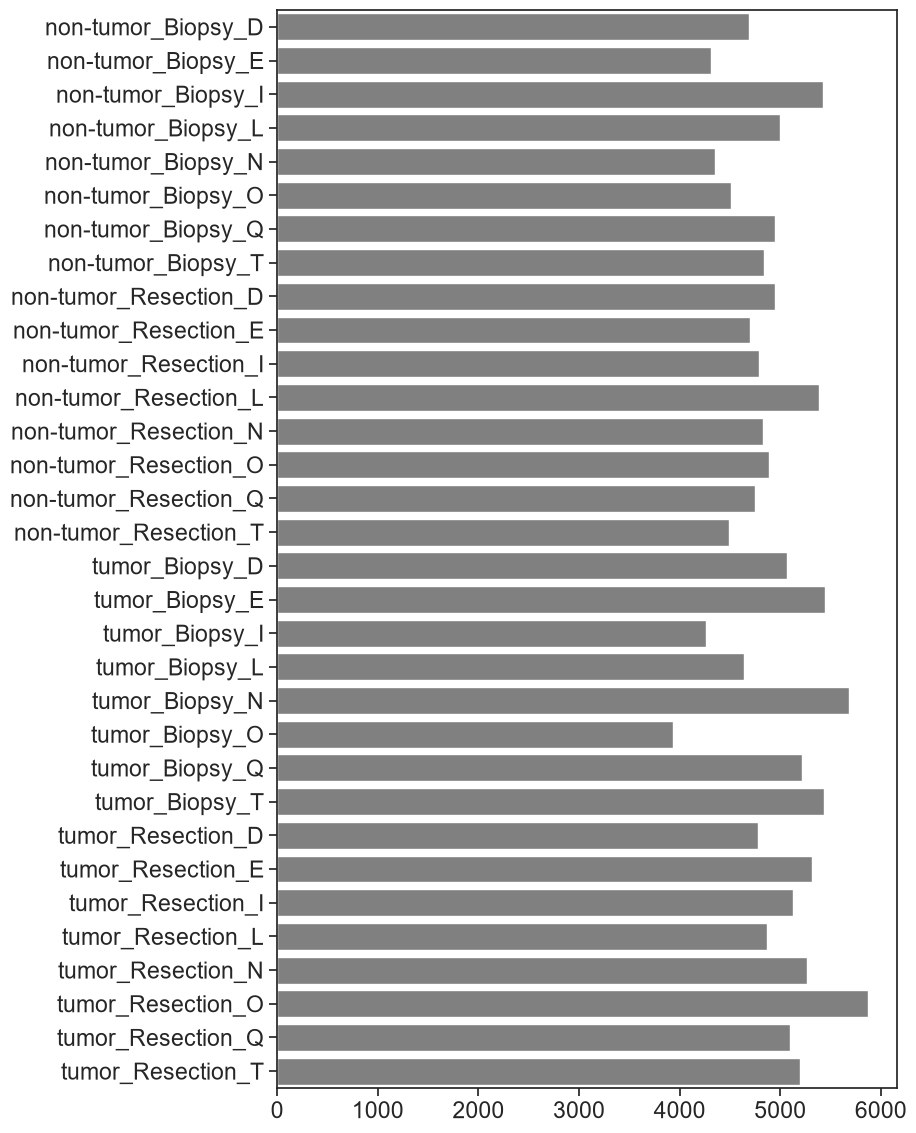

In [142]:
fig, ax = plt.subplots(figsize=(8,14))
sns.barplot(df_out, color='grey', orient='h')
plt.savefig('figures/protein_ids_per_sample.png')

## 6. Split tissues and log2-transform intensities

Create aligned non-tumor and HCC matrices and metadata; the two tissues are analyzed independently.

In [143]:
metadata = meta_prot.loc[:,['Sample_type', 'Sex', 'Age', 'Tissue',
                           'Seq_id', 'patient_id', 'col_names',
                           'Time between resection and biopsy',
                           'Total surgery time', 'necrosis',
                            'nontumor',	'stroma', 'tumor']].copy()
metadata.index = metadata.Seq_id
metadata_liver = metadata[metadata.Tissue == 'non-tumor'].copy()
metadata_hcc = metadata[metadata.Tissue == 'tumor'].copy()

In [144]:
metadata_liver.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,necrosis,nontumor,stroma,tumor
Seq_id,,,,,,,,,,,,,
011_BR-LF-3_C21,Biopsy,F,70.0,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0
013_BR-LF-3_C21,Biopsy,M,60.0,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0
020_BR-LF-3_C21,Biopsy,M,78.0,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28.0,0.0,33.0,0.0,3.0,64.0
022_BR-LF-3_C21,Biopsy,F,70.0,non-tumor,022_BR-LF-3_C21,Q,non-tumor_Biopsy_Q,32.0,0.0,NaN,NaN,NaN,NaN
024_BR-LF-3_C21,Biopsy,F,54.0,non-tumor,024_BR-LF-3_C21,I,non-tumor_Biopsy_I,30.0,0.0,0.0,8.0,17.0,75.0


In [145]:
# Log2 transform
df_log = np.log2(df_n)
df_log.head()

Run,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.583744,23.631907,23.227478,23.706333,22.691730,23.700348,23.783178,23.720911,23.182013,22.583464,22.796499,22.783865,23.628981,23.128525,23.448261,23.453941,23.255272,22.270475,24.026705,23.613865,22.353943,23.569225,23.161396,22.659174,22.967411,21.406275,22.423550,22.785063,22.219536,22.301674,22.981184,21.408100
A1CF,23.080559,23.104027,22.957027,22.424751,23.435858,22.928110,22.980057,23.153534,23.178709,23.273979,23.201015,22.328712,23.274574,23.463631,23.130199,23.366055,22.648235,21.974596,22.523945,23.249437,21.949207,22.197075,22.566017,23.312183,22.577009,22.447262,22.686665,22.996695,22.293673,22.284140,22.376797,23.050961
A2M,25.333908,25.927792,24.362339,25.778812,24.084978,26.270123,26.097136,23.918167,23.939219,23.917244,23.307871,23.845980,25.212572,24.586401,25.354807,23.439011,24.140676,23.947323,25.168591,24.995989,24.282225,26.508230,25.480110,23.044794,23.881674,22.996946,22.701815,23.112858,23.141455,23.304840,24.875446,21.337704
AAAS,17.384706,17.169897,17.184856,17.239319,16.505604,17.065168,17.483335,17.359283,15.732097,16.796206,16.714172,17.126320,17.161808,NaN,17.370012,17.545244,17.742456,17.787691,17.346569,17.171499,17.001955,NaN,18.114475,18.056957,17.265703,17.633694,16.964922,16.974493,17.282082,18.008360,17.719534,17.202330
AACS,15.870167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.295835,16.375607,NaN,NaN,NaN,15.806023,NaN,16.039684,NaN,15.229109,NaN,NaN


In [146]:
df_liver = df_log.loc[:,metadata_liver.col_names].copy()
# df_liver['Gene'] = df_n['PG.Genes']
# df_liver['ID'] = df_n['PG.ProteinGroups']
# df_liver.index = df_liver.ID

df_hcc = df_log.loc[:,metadata_hcc.col_names].copy()
# df_hcc['Gene'] = df_n['PG.Genes']
# df_hcc['ID'] = df_n['PG.ProteinGroups']
# df_hcc.index = df_hcc.ID

In [147]:
df_log.shape[0] - df_log.isna().sum()

Run
non-tumor_Biopsy_D       4689
non-tumor_Biopsy_E       4312
non-tumor_Biopsy_I       5427
non-tumor_Biopsy_L       5000
non-tumor_Biopsy_N       4356
non-tumor_Biopsy_O       4508
non-tumor_Biopsy_Q       4946
non-tumor_Biopsy_T       4834
non-tumor_Resection_D    4944
non-tumor_Resection_E    4696
non-tumor_Resection_I    4792
non-tumor_Resection_L    5388
non-tumor_Resection_N    4833
non-tumor_Resection_O    4884
non-tumor_Resection_Q    4753
non-tumor_Resection_T    4495
tumor_Biopsy_D           5069
tumor_Biopsy_E           5446
tumor_Biopsy_I           4262
tumor_Biopsy_L           4636
tumor_Biopsy_N           5686
tumor_Biopsy_O           3934
tumor_Biopsy_Q           5214
tumor_Biopsy_T           5432
tumor_Resection_D        4779
tumor_Resection_E        5319
tumor_Resection_I        5127
tumor_Resection_L        4864
tumor_Resection_N        5268
tumor_Resection_O        5869
tumor_Resection_Q        5099
tumor_Resection_T        5198
dtype: int64

## 7. Sample-level proteomics QC

Summarize and visualize per-sample quantified-feature counts.

In [148]:
# QC

metadata_qc = metadata.copy()
metadata_qc.index = metadata_qc.col_names

metadata_qc['counts'] = df_log.shape[0] - df_log.isna().sum()

In [149]:
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,necrosis,nontumor,stroma,tumor,counts
col_names,,,,,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70.0,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0,4689
tumor_Biopsy_D,Biopsy,F,70.0,tumor,012_BR-LF-3_C21,D,tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0,5069
non-tumor_Biopsy_N,Biopsy,M,60.0,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0,4356
tumor_Biopsy_N,Biopsy,M,60.0,tumor,014_BR-LF-3_C21,N,tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0,5686
non-tumor_Biopsy_O,Biopsy,M,78.0,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28.0,0.0,33.0,0.0,3.0,64.0,4508


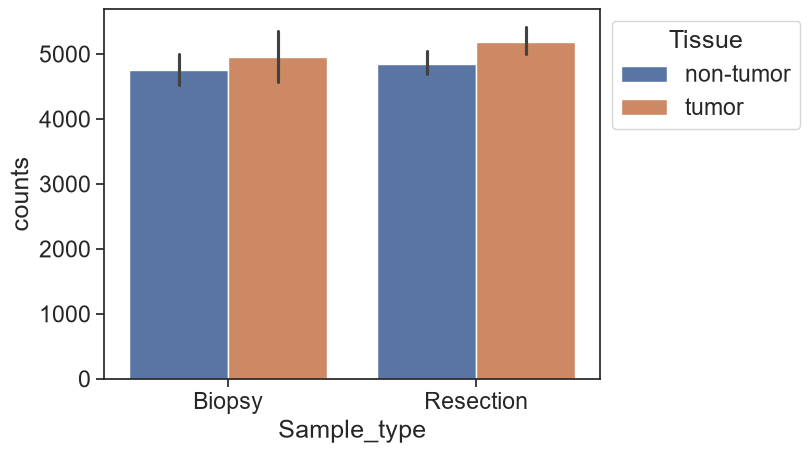

In [150]:
ax = sns.barplot(data=metadata_qc, x='Sample_type', y='counts', hue='Tissue')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.savefig('proteomics_qc_protein_ids.pdf', bbox_inches='tight', dpi=300)


In [151]:
metadata_qc.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,necrosis,nontumor,stroma,tumor,counts
col_names,,,,,,,,,,,,,,
non-tumor_Biopsy_D,Biopsy,F,70.0,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0,4689
tumor_Biopsy_D,Biopsy,F,70.0,tumor,012_BR-LF-3_C21,D,tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0,5069
non-tumor_Biopsy_N,Biopsy,M,60.0,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0,4356
tumor_Biopsy_N,Biopsy,M,60.0,tumor,014_BR-LF-3_C21,N,tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0,5686
non-tumor_Biopsy_O,Biopsy,M,78.0,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28.0,0.0,33.0,0.0,3.0,64.0,4508


In [152]:
res_list = []
for var in metadata_qc.Tissue.unique():
    subset = metadata_qc[metadata_qc.Tissue == var]
    print(var)
    res = stats.ttest_ind(subset[subset.Sample_type == 'Biopsy'].counts, subset[subset.Sample_type == 'Resection'].counts)
    print(res)
    print('\n')
    res_list.append(var)
    res_list.append(res)

    

    
with open('proteomics_qc_ttest.csv', 'w', newline='') as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    wr.writerow(res_list)

non-tumor
TtestResult(statistic=np.float64(-0.5563275783762038), pvalue=np.float64(0.5867696451507368), df=np.float64(14.0))


tumor
TtestResult(statistic=np.float64(-0.9248337048288412), pvalue=np.float64(0.37071963770172495), df=np.float64(14.0))




## 8. Missingness filtering and KNN imputation

Apply the minimum-observation rule, then fit three-neighbor KNN imputation separately within biopsy and resection samples to avoid cross-condition borrowing.

In [153]:


imputer = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=True
)
imputer_ = KNNImputer(
    n_neighbors=3,     # small k due to small sample size
    weights='uniform', # or 'distance' if closer samples should weigh more
    metric='nan_euclidean',  # default metric, handles missing values
    add_indicator=False
)
imputer.set_output(transform='pandas')
imputer_.set_output(transform='pandas')

,"n_neighbors n_neighbors: int, default=5Number of neighboring samples to use for imputation.",3
,"missing_values missing_values: int, float, str, np.nan or None, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`should be set to np.nan, since `pd.NA` will be converted to np.nan.",nan
,"weights weights: {'uniform', 'distance'} or callable, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- callable : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.",'uniform'
,"metric metric: {'nan_euclidean'} or callable, default='nan_euclidean'Distance metric for searching neighbors. Possible values:- 'nan_euclidean'- callable : a user-defined function which conforms to the definition of ``func_metric(x, y, *, missing_values=np.nan)``. `x` and `y` corresponds to a row (i.e. 1-D arrays) of `X` and `Y`, respectively. The callable should returns a scalar distance value.",'nan_euclidean'
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto theoutput of the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear on themissing indicator even if there are missing values at transform/testtime.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0`... versionadded:: 1.2",False


In [154]:
df_liver.shape

(8069, 16)

In [155]:
# at least 4 valid values
df_liver = df_liver.dropna(thresh=4)
df_hcc = df_hcc.dropna(thresh=4)
print(df_liver.shape)

# at least one valid value per condition
df_liver = df_liver.dropna(thresh=1, subset=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names)
df_liver = df_liver.dropna(thresh=1, subset=metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names)
print(df_liver.shape)

df_hcc = df_hcc.dropna(thresh=1, subset=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names)
df_hcc = df_hcc.dropna(thresh=1, subset=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names)

(5499, 16)
(5454, 16)


In [156]:
df_liver.head()

Run,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Biopsy_L,non-tumor_Biopsy_E,non-tumor_Resection_L,non-tumor_Resection_E
Genes,,,,,,,,,,,,,,,,
A1BG,23.583744,22.691730,23.700348,23.783178,23.227478,23.720911,23.182013,23.628981,23.128525,23.448261,23.453941,22.796499,23.706333,23.631907,22.783865,22.583464
A1CF,23.080559,23.435858,22.928110,22.980057,22.957027,23.153534,23.178709,23.274574,23.463631,23.130199,23.366055,23.201015,22.424751,23.104027,22.328712,23.273979
A2M,25.333908,24.084978,26.270123,26.097136,24.362339,23.918167,23.939219,25.212572,24.586401,25.354807,23.439011,23.307871,25.778812,25.927792,23.845980,23.917244
AAAS,17.384706,16.505604,17.065168,17.483335,17.184856,17.359283,15.732097,17.161808,NaN,17.370012,17.545244,16.714172,17.239319,17.169897,17.126320,16.796206
AADAC,22.620520,21.969687,21.337917,21.287830,21.983412,21.202602,20.642092,21.451967,20.851093,21.695572,21.056515,21.790756,21.013498,21.389828,20.498693,20.994833


In [157]:
# Seperatly per condition

df_liver_biop = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Biopsy'].col_names])
df_liver_rese = imputer.fit_transform(df_liver.loc[:,metadata_liver[metadata_liver.Sample_type == 'Resection'].col_names])

df_hcc_biop = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].col_names])
df_hcc_rese = imputer.fit_transform(df_hcc.loc[:,metadata_hcc[metadata_hcc.Sample_type == 'Resection'].col_names])


# For PCA with all samples
df_all = pd.concat([df_liver_biop, df_liver_rese, df_hcc_biop, df_hcc_rese], axis=1)
df_all = df_all.loc[:,[x for x in df_all.columns if not x.startswith('missing')]]
df_all = imputer_.fit_transform(df_all)

In [158]:
df_liver_imputed = pd.concat([df_liver_biop, df_liver_rese], axis=1)
df_liver_imputed.to_csv(f'proteomics_imputed_liver_{today}.csv')

df_hcc_imputed = pd.concat([df_hcc_biop, df_hcc_rese], axis=1)
df_hcc_imputed.to_csv(f'proteomics_imputed_hcc_{today}.csv')

In [159]:
df_liver_imputed.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.583744,22.691730,23.700348,23.783178,23.227478,23.720911,23.706333,23.631907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.182013,23.628981,23.128525,23.448261,23.453941,22.796499,22.783865,22.583464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,23.080559,23.435858,22.928110,22.980057,22.957027,23.153534,22.424751,23.104027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.178709,23.274574,23.463631,23.130199,23.366055,23.201015,22.328712,23.273979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,25.333908,24.084978,26.270123,26.097136,24.362339,23.918167,25.778812,25.927792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.939219,25.212572,24.586401,25.354807,23.439011,23.307871,23.845980,23.917244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.384706,16.505604,17.065168,17.483335,17.184856,17.359283,17.239319,17.169897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.732097,17.161808,15.998487,17.370012,17.545244,16.714172,17.126320,16.796206,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
AADAC,22.620520,21.969687,21.337917,21.287830,21.983412,21.202602,21.013498,21.389828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.642092,21.451967,20.851093,21.695572,21.056515,21.790756,20.498693,20.994833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [160]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.255272,22.353943,23.569225,23.161396,24.026705,22.659174,23.613865,22.270475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.967411,22.219536,22.301674,22.981184,21.408100,22.423550,22.785063,21.406275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.648235,21.949207,22.197075,22.566017,22.523945,23.312183,23.249437,21.974596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.577009,22.293673,22.284140,22.376797,23.050961,22.686665,22.996695,22.447262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.140676,24.282225,26.508230,25.480110,25.168591,23.044794,24.995989,23.947323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.881674,23.141455,23.304840,24.875446,21.337704,22.701815,23.112858,22.996946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.742456,17.001955,17.750624,18.114475,17.346569,18.056957,17.171499,17.787691,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.265703,17.282082,18.008360,17.719534,17.202330,16.964922,16.974493,17.633694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.387304,16.295835,16.375607,16.317015,16.930548,16.818823,17.347580,16.177885,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,16.143217,15.985530,15.229109,16.047270,15.980369,16.047676,16.039684,15.806023,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [161]:
df_liver_imputed.shape

(5454, 32)

## 9. Correlation and imputation diagnostics

Inspect sample correlations and compare observed with imputed intensity distributions for each tissue.

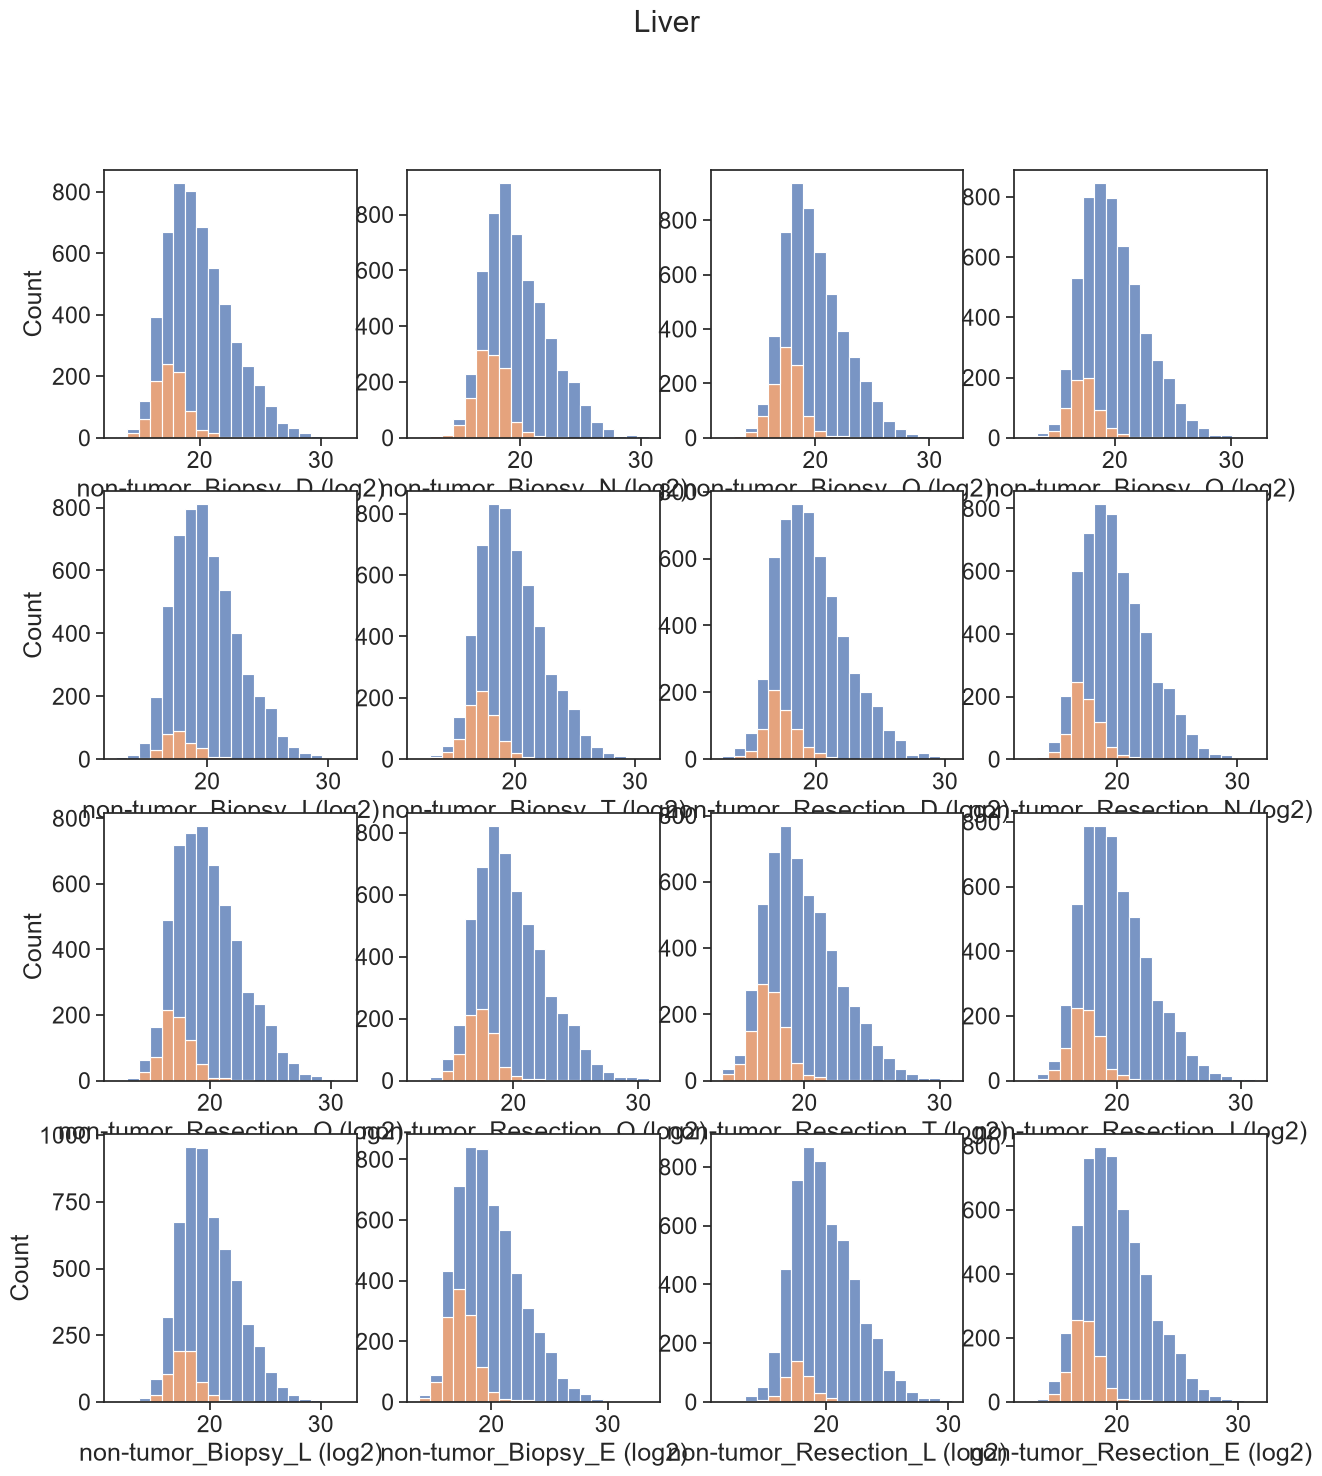

In [164]:
# Histograms of imputed values

# Create the subplots
n_rows = math.ceil(len(metadata_liver.col_names)/4)
fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_liver.col_names)))

for i, col in enumerate(metadata_liver.col_names):    
    imp_col = 'missingindicator_' + col
    sns.histplot(df_liver_imputed, x=col, ax=axes[i//4,i%4],
                 hue=imp_col, legend=False, bins=20, multiple="stack")
    
    axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
    if i == 0 or i%4 == 0:
        axes[i//4,i%4].set(ylabel='Count')
    else:
        axes[i//4,i%4].set(ylabel='')
    fig.suptitle('Liver')
#     if len(cols) < 12:
#         fig.delaxes(axes[i//4,i%4])
plt.savefig(f'figures/liver_imputed_values_{today}.pdf', bbox_inches='tight')
plt.show()
plt.close()
    

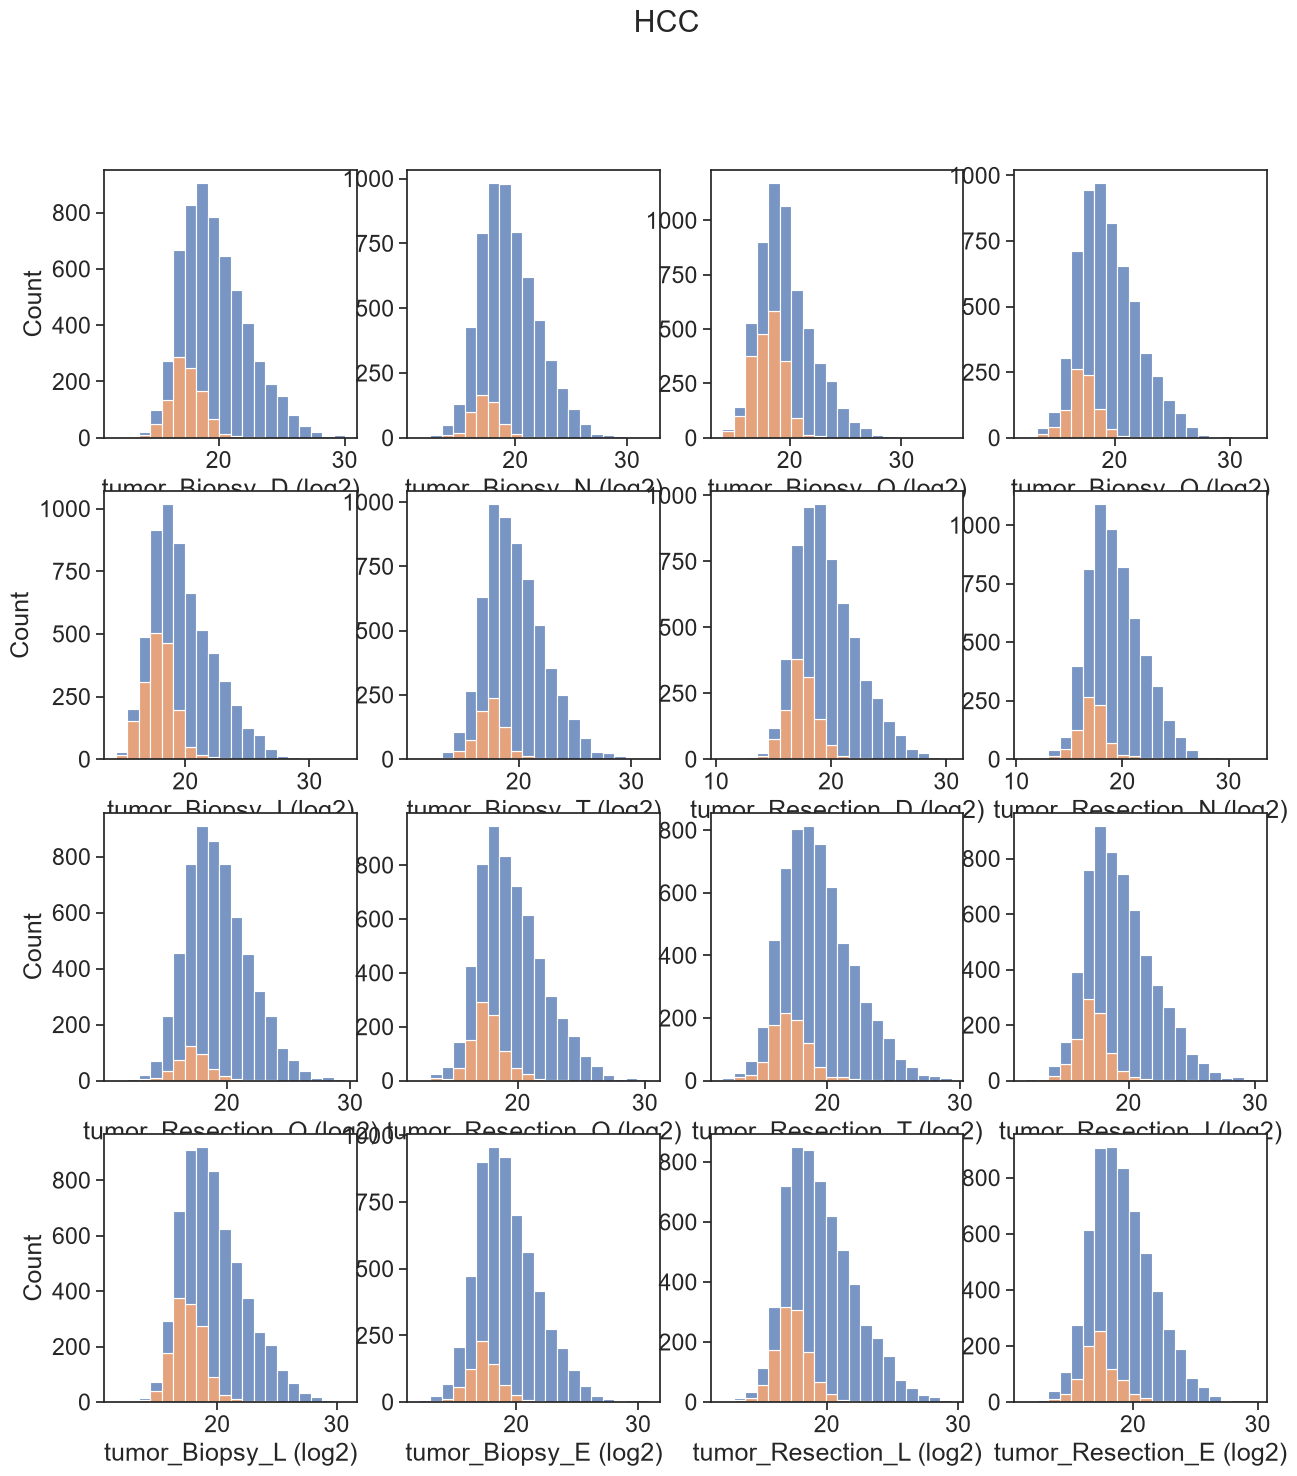

In [165]:
# HCC
# Create the subplots
n_rows = math.ceil(len(metadata_hcc.col_names)/4)
fig, axes = plt.subplots(nrows=n_rows, ncols=4, figsize=(15, len(metadata_hcc.col_names)))

for i, col in enumerate(metadata_hcc.col_names):    
    imp_col = 'missingindicator_' + col
    sns.histplot(df_hcc_imputed, x=col, ax=axes[i//4,i%4],
                 hue=imp_col, legend=False, bins=20, multiple="stack")
    
    axes[i//4,i%4].set(xlabel=col + ' (log2)')
    
    if i == 0 or i%4 == 0:
        axes[i//4,i%4].set(ylabel='Count')
    else:
        axes[i//4,i%4].set(ylabel='')
    fig.suptitle('HCC')
#     if len(cols) < 12:
#         fig.delaxes(axes[i//4,i%4])
plt.savefig(f'figures/hcc_imputed_values_{today}.pdf', bbox_inches='tight')
plt.show()
plt.close()

## 10. Paired limma sensitivity analysis without imputation

Fit patient-blocked empirical-Bayes linear models to features with sufficient complete pairs, retaining missing values rather than imputing them.

In [166]:
metadata.head()

,Sample_type,Sex,Age,Tissue,Seq_id,patient_id,col_names,Time between resection and biopsy,Total surgery time,necrosis,nontumor,stroma,tumor
Seq_id,,,,,,,,,,,,,
011_BR-LF-3_C21,Biopsy,F,70.0,non-tumor,011_BR-LF-3_C21,D,non-tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0
012_BR-LF-3_C21,Biopsy,F,70.0,tumor,012_BR-LF-3_C21,D,tumor_Biopsy_D,29.0,0.0,0.0,24.0,29.0,47.0
013_BR-LF-3_C21,Biopsy,M,60.0,non-tumor,013_BR-LF-3_C21,N,non-tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0
014_BR-LF-3_C21,Biopsy,M,60.0,tumor,014_BR-LF-3_C21,N,tumor_Biopsy_N,15.0,0.0,12.0,0.0,24.0,64.0
020_BR-LF-3_C21,Biopsy,M,78.0,non-tumor,020_BR-LF-3_C21,O,non-tumor_Biopsy_O,28.0,0.0,33.0,0.0,3.0,64.0


In [167]:
print("InMoose version:", version("inmoose"))


# Columns already visible in your code
SAMPLE_COL = "col_names"
METHOD_COL = "Sample_type"

# Replace this with the exact participant/patient column in your metadata
PARTICIPANT_COL = "patient_id"

REFERENCE_METHOD = "Biopsy"
COMPARISON_METHOD = "Resection"

InMoose version: 0.9.1


In [168]:
def _standardize_inmoose_columns(results):
    """
    Standardize column names across different InMoose versions.
    """

    rename_map = {
        # Effect size
        "logFC": "log2FoldChange",

        # Moderated statistic
        "t": "stat",

        # Raw p-value
        "P.Value": "pvalue",
        "P_Value": "pvalue",

        # Adjusted p-value
        "adj.P.Val": "adj_pvalue",
        "adj_P_Value": "adj_pvalue",
    }

    return results.rename(columns=rename_map)


def run_paired_limma(
    expression,
    metadata,
    *,
    sample_col,
    participant_col,
    method_col,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=True,
):
    """
    Paired limma analysis using within-participant differences.

    The tested quantity is:

        comparison - reference

    For example:

        Resection - Biopsy

    Parameters
    ----------
    expression : pandas.DataFrame
        Feature x sample matrix of original log2 intensities.
        Missing values must remain NaN. Do not use KNN-imputed values.

    metadata : pandas.DataFrame
        Sample metadata.

    sample_col : str
        Metadata column containing expression-matrix column names.

    participant_col : str
        Participant/patient identifier.

    method_col : str
        Collection-method column.

    reference : str
        Reference collection method.

    comparison : str
        Collection method compared against the reference.

    min_complete_pairs : int
        Minimum number of participants with both measurements available
        for a feature.

    trend : bool
        If True, estimate an abundance-dependent prior variance trend.

    robust : bool
        Use robust empirical-Bayes variance moderation.

    Returns
    -------
    dict
        results
        fit
        design
        matrix
        pair_table
        paired_samples
        filter_summary
    """

    # -------------------------------------------------------------
    # 1. Validate and standardize expression matrix
    # -------------------------------------------------------------

    expr = expression.copy()

    if expr.index.has_duplicates:
        duplicates = (
            expr.index[expr.index.duplicated()]
            .unique()
            .tolist()
        )

        raise ValueError(
            "Expression feature IDs are duplicated. "
            f"Examples: {duplicates[:10]}"
        )

    expr.columns = expr.columns.astype(str)

    expr = expr.apply(
        pd.to_numeric,
        errors="coerce",
    )

    expr = expr.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # -------------------------------------------------------------
    # 2. Validate and subset metadata
    # -------------------------------------------------------------

    required_columns = [
        sample_col,
        participant_col,
        method_col,
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in metadata.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Metadata columns not found: {missing_columns}"
        )

    md = metadata[required_columns].copy()

    md = md.dropna(
        subset=required_columns
    )

    md[sample_col] = md[sample_col].astype(str)
    md[participant_col] = md[participant_col].astype(str)
    md[method_col] = (
        md[method_col]
        .astype(str)
        .str.strip()
    )

    # Keep only samples present in the expression matrix
    md = md.loc[
        md[sample_col].isin(expr.columns)
    ].copy()

    # Keep only the two methods being compared
    md = md.loc[
        md[method_col].isin(
            [reference, comparison]
        )
    ].copy()

    if md.empty:
        raise ValueError(
            "No matching metadata samples were found."
        )

    # -------------------------------------------------------------
    # 3. Require one sample per participant and method
    # -------------------------------------------------------------

    duplicated_pairs = md.duplicated(
        subset=[
            participant_col,
            method_col,
        ],
        keep=False,
    )

    if duplicated_pairs.any():
        duplicate_table = md.loc[
            duplicated_pairs,
            [
                sample_col,
                participant_col,
                method_col,
            ],
        ].sort_values(
            [
                participant_col,
                method_col,
            ]
        )

        raise ValueError(
            "More than one sample was found for at least one "
            "participant/method combination. Aggregate technical "
            "replicates first.\n\n"
            f"{duplicate_table}"
        )

    # -------------------------------------------------------------
    # 4. Match paired samples
    # -------------------------------------------------------------

    pair_table = md.pivot(
        index=participant_col,
        columns=method_col,
        values=sample_col,
    )

    if reference not in pair_table.columns:
        raise ValueError(
            f"No '{reference}' samples were found."
        )

    if comparison not in pair_table.columns:
        raise ValueError(
            f"No '{comparison}' samples were found."
        )

    pair_table = pair_table.dropna(
        subset=[
            reference,
            comparison,
        ]
    )

    if pair_table.empty:
        raise ValueError(
            "No participants had both collection methods."
        )

    # Expression columns used in the analysis
    paired_samples = []

    for participant in pair_table.index:
        paired_samples.extend(
            [
                pair_table.loc[
                    participant,
                    reference,
                ],
                pair_table.loc[
                    participant,
                    comparison,
                ],
            ]
        )

    # -------------------------------------------------------------
    # 5. Calculate within-participant differences
    # -------------------------------------------------------------

    paired_differences = pd.DataFrame(
        index=expr.index
    )

    for participant, pair in pair_table.iterrows():

        reference_sample = pair[reference]
        comparison_sample = pair[comparison]

        paired_differences[participant] = (
            expr[comparison_sample]
            - expr[reference_sample]
        )

    # A difference is NaN when either member of the pair is missing
    n_complete_pairs = (
        paired_differences
        .notna()
        .sum(axis=1)
        .astype(int)
    )

    keep = (
        n_complete_pairs
        >= min_complete_pairs
    )

    tested_differences = (
        paired_differences
        .loc[keep]
        .copy()
    )

    if tested_differences.empty:
        raise ValueError(
            "No features passed the minimum complete-pair threshold."
        )

    # -------------------------------------------------------------
    # 6. Calculate abundance for limma-trend
    # -------------------------------------------------------------

    raw_paired_matrix = expr.loc[
        tested_differences.index,
        paired_samples,
    ]

    mean_log2_intensity = (
        raw_paired_matrix
        .mean(axis=1, skipna=True)
    )

    # For an intercept-only difference model, the default Amean from
    # lmFit would be the mean difference, not the mean abundance.
    # Therefore, explicitly provide mean abundance as the trend
    # covariate.
    if trend:
        trend_argument = (
            mean_log2_intensity
            .to_numpy(dtype=float)
        )
    else:
        trend_argument = False

    # -------------------------------------------------------------
    # 7. Intercept-only paired-difference model
    # -------------------------------------------------------------
    
    design_metadata = pd.DataFrame(
        {
            "paired_difference": np.ones(
                tested_differences.shape[1],
                dtype=float,
            )
        },
        index=tested_differences.columns,
    )
    
    # Keep this as a Patsy DesignMatrix so InMoose preserves
    # the coefficient name in design_info.
    design = dmatrix(
        "0 + paired_difference",
        data=design_metadata,
        return_type="matrix",
    )
    
    fit = lmFit(
        tested_differences,
        design=design,
    )
    
    fit = eBayes(
        fit,
        trend=trend_argument,
        robust=False,
    )
    
    
    # -------------------------------------------------------------
    # 8. Extract all tested features
    # -------------------------------------------------------------
    
    # Do not assume that InMoose retained a specific name.
    # Read the actual coefficient name from the fitted object.
    coefficient_names = fit.coefficients.columns.tolist()
    
    if len(coefficient_names) != 1:
        raise RuntimeError(
            "Expected exactly one coefficient in the paired-difference "
            f"model, but found: {coefficient_names}"
        )
    
    method_coefficient = coefficient_names[0]
    
    print(
        "Coefficient tested by topTable:",
        method_coefficient,
    )
    
    results = topTable(
        fit,
        coef=method_coefficient,
        number=tested_differences.shape[0],
        adjust_method="fdr_bh",
        sort_by="P",
        p_value=1.0,
    )
    
    results = pd.DataFrame(results)
    results = _standardize_inmoose_columns(results)

    # -------------------------------------------------------------
    # 9. Add missingness diagnostics
    # -------------------------------------------------------------

    diagnostics = pd.DataFrame(
        index=tested_differences.index
    )

    diagnostics["n_complete_pairs"] = (
        n_complete_pairs.loc[
            tested_differences.index
        ]
    )

    diagnostics["n_incomplete_pairs"] = (
        pair_table.shape[0]
        - diagnostics["n_complete_pairs"]
    )

    diagnostics["incomplete_pair_fraction"] = (
        diagnostics["n_incomplete_pairs"]
        / pair_table.shape[0]
    )

    diagnostics["n_raw_observed_values"] = (
        raw_paired_matrix
        .notna()
        .sum(axis=1)
    )

    diagnostics["n_raw_missing_values"] = (
        raw_paired_matrix
        .isna()
        .sum(axis=1)
    )

    diagnostics["raw_missing_fraction"] = (
        raw_paired_matrix
        .isna()
        .mean(axis=1)
    )

    diagnostics["mean_log2_intensity"] = (
        mean_log2_intensity
    )

    results = diagnostics.join(
        results,
        how="left",
    )

    results["effect"] = (
        f"{comparison} - {reference}"
    )

    if "adj_pvalue" in results.columns:
        results["significant_FDR_0.05"] = (
            results["adj_pvalue"] < 0.05
        )

        results = results.sort_values(
            [
                "adj_pvalue",
                "pvalue",
            ],
            na_position="last",
        )

    # -------------------------------------------------------------
    # 10. Analysis summary
    # -------------------------------------------------------------

    filter_summary = pd.Series(
        {
            "features_input": expr.shape[0],
            "features_tested": tested_differences.shape[0],
            "features_excluded": (
                expr.shape[0] - tested_differences.shape[0]
            ),
            "participants_with_both_methods": pair_table.shape[0],
            "minimum_complete_pairs": min_complete_pairs,
            "reference_method": reference,
            "comparison_method": comparison,
            "effect_definition": f"{comparison} - {reference}",
            "limma_coefficient": method_coefficient,
            "variance_moderation": "limma empirical Bayes",
            "robust_empirical_bayes": False,
            "abundance_trend": trend,
            "imputation_used_for_testing": False,
        },
        name="analysis_summary",
    )

    return {
        "results": results,
        "fit": fit,
        "design": pd.DataFrame(
            np.asarray(design),
            index=tested_differences.columns,
            columns=design.design_info.column_names,
        ),
        "matrix": tested_differences,
        "all_differences": paired_differences,
        "pair_table": pair_table,
        "paired_samples": paired_samples,
        "mean_log2_intensity": mean_log2_intensity,
        "filter_summary": filter_summary,
    }

In [169]:
df_liver.isna().sum()

Run
non-tumor_Biopsy_D        857
non-tumor_Biopsy_N       1159
non-tumor_Biopsy_O       1029
non-tumor_Biopsy_Q        660
non-tumor_Biopsy_I        311
non-tumor_Biopsy_T        727
non-tumor_Resection_D     637
non-tumor_Resection_N     737
non-tumor_Resection_O     700
non-tumor_Resection_Q     785
non-tumor_Resection_T    1032
non-tumor_Resection_I     781
non-tumor_Biopsy_L        635
non-tumor_Biopsy_E       1189
non-tumor_Resection_L     398
non-tumor_Resection_E     843
dtype: int64

In [170]:
liver_limma = run_paired_limma(
    expression=df_liver,
    metadata=metadata_liver,
    sample_col=SAMPLE_COL,
    participant_col=PARTICIPANT_COL,
    method_col=METHOD_COL,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=False, # not implemented
)

Coefficient tested by topTable: paired_difference


In [171]:
print(liver_limma["fit"].coefficients.columns.tolist())
display(liver_limma["design"])
display(liver_limma["filter_summary"].to_frame())
display(liver_limma["results"].head())

['paired_difference']


,paired_difference
D,1.0
E,1.0
I,1.0
L,1.0
N,1.0
O,1.0
Q,1.0
T,1.0


,analysis_summary
features_input,5454
features_tested,4379
features_excluded,1075
participants_with_both_methods,8
minimum_complete_pairs,4
reference_method,Biopsy
comparison_method,Resection
effect_definition,Resection - Biopsy
limma_coefficient,paired_difference
variance_moderation,limma empirical Bayes


,n_complete_pairs,n_incomplete_pairs,incomplete_pair_fraction,n_raw_observed_values,n_raw_missing_values,raw_missing_fraction,mean_log2_intensity,log2FoldChange,lfcSE,AveExpr,stat,pvalue,adj_pvalue,B,effect,significant_FDR_0.05
Genes,,,,,,,,,,,,,,,,
RPS12,8,0,0.000,16,0,0.0000,24.339617,0.858695,0.353553,0.858695,9.523548,6.991414e-07,0.002130,6.158040,Resection - Biopsy,True
LAMTOR3,7,1,0.125,15,1,0.0625,18.701508,-1.260998,0.377964,-1.260998,-9.884948,9.726241e-07,0.002130,6.382893,Resection - Biopsy,True
COX7A2,8,0,0.000,16,0,0.0000,21.705036,-1.155789,0.353553,-1.155789,-8.558075,2.125213e-06,0.003102,5.197068,Resection - Biopsy,True
IGKV3-11,8,0,0.000,16,0,0.0000,23.100170,-1.017438,0.353553,-1.017438,-7.585545,7.187411e-06,0.007437,4.108950,Resection - Biopsy,True
COX7C,8,0,0.000,16,0,0.0000,20.456713,-1.341125,0.353553,-1.341125,-7.458816,8.491630e-06,0.007437,3.957525,Resection - Biopsy,True


In [172]:
hcc_limma = run_paired_limma(
    expression=df_hcc,
    metadata=metadata_hcc,
    sample_col=SAMPLE_COL,
    participant_col=PARTICIPANT_COL,
    method_col=METHOD_COL,
    reference="Biopsy",
    comparison="Resection",
    min_complete_pairs=4,
    trend=True,
    robust=False, #not implemented
)

Coefficient tested by topTable: paired_difference


## 11. PCA overview

Fit global and tissue-specific PCA models after scaling the selected proteomic features.

In [173]:
scaler = StandardScaler()
pca = PCA(n_components=10)

In [174]:
hue_order=['Biopsy', 'Resection']

In [175]:
metadata_liver.index = metadata_liver.col_names

metadata_hcc.index = metadata_hcc.col_names

In [176]:
df_all_pca = df_all.copy()
df_all_pca['expression_std'] = df_all_pca.std(axis=1)
df_all_pca = df_all_pca.sort_values('expression_std', ascending=False)
df_all_pca = df_all_pca.iloc[:500,:-1]
df_all_pca.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
GSTA2,27.610729,24.982264,23.016195,26.673605,27.107075,23.784918,23.354168,25.367712,25.897112,26.831614,23.483067,27.231197,24.629770,27.586073,23.869535,25.246922,26.661030,23.903467,18.570923,25.000931,24.970066,21.140785,23.129520,19.995731,26.761335,22.473764,18.238993,24.528971,22.376951,28.114010,22.453077,18.997971
AKR1B10,20.849844,22.925726,23.523224,20.161366,21.306646,24.698074,23.468206,21.611914,22.121305,21.352560,21.859142,20.777063,24.352423,21.328121,23.043844,21.535622,28.153831,25.278255,26.773317,25.797268,25.025173,23.843904,27.055058,22.527334,27.812387,25.729778,26.675993,26.225962,27.834896,19.538872,26.904665,23.479921
GSTT1,24.006834,22.756077,22.957144,16.347830,23.426413,22.831161,16.603271,23.318584,23.895580,23.292543,23.239256,23.213486,23.123972,23.307735,23.523031,23.464909,22.677895,22.391119,21.996622,18.798351,22.289606,23.061888,18.188227,21.162811,23.310169,22.742996,22.568747,16.094782,22.298393,22.215565,17.369753,21.673609
DNAJB9,19.212294,22.638548,18.895935,18.942650,24.321621,24.231211,18.464952,24.600739,18.649784,22.708693,19.788454,18.462769,24.735140,25.137182,19.272488,24.767479,18.738794,19.965206,20.656252,23.003082,23.563927,20.561012,19.102732,21.675667,19.913574,19.020166,19.796494,19.241484,19.470238,21.464413,18.705273,19.999416
LOXL1,23.812284,18.855888,23.817514,20.866838,20.747890,19.457706,19.166059,19.041159,25.058401,18.943977,22.124365,19.281418,19.189245,17.461323,19.341295,18.608393,22.371746,19.287144,17.310572,20.349569,22.044458,18.842367,17.090067,16.530569,23.299957,18.236984,17.969606,20.561007,16.563856,16.540125,18.756716,18.059805


In [177]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_all_pca.T)
pca = PCA(n_components=10)

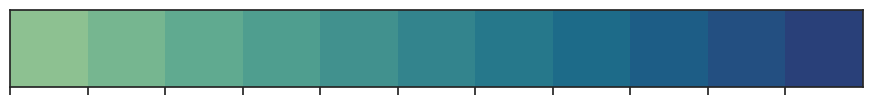

In [178]:
palette = sns.color_palette('crest', 11)
sns.palplot(palette)
plt.savefig('pca_tissue_composition_cmap.pdf')
plt.show()

In [179]:
metadata.index = metadata.col_names

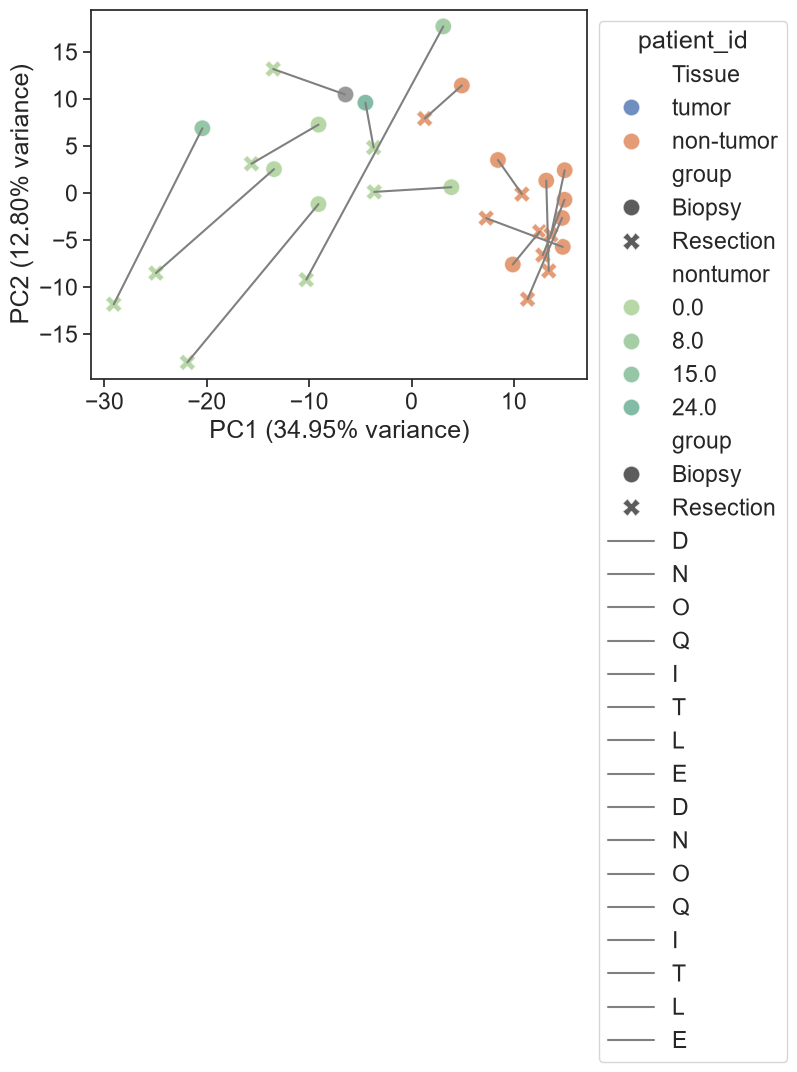

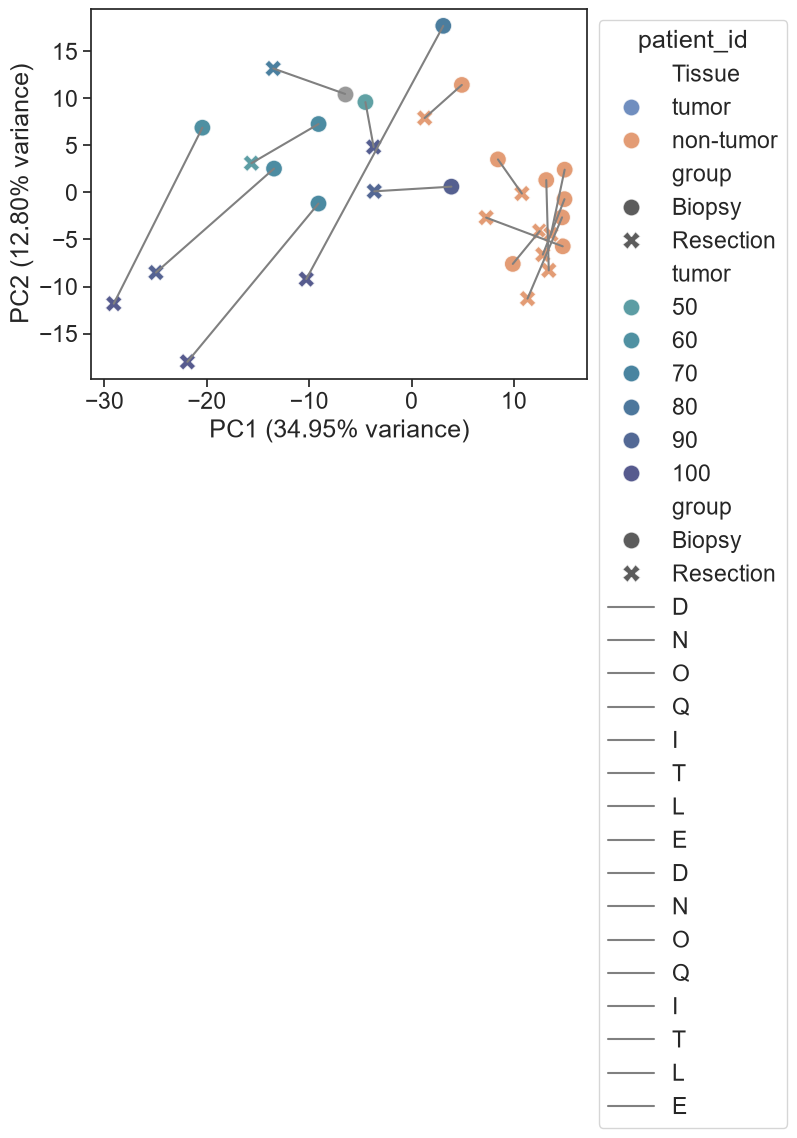

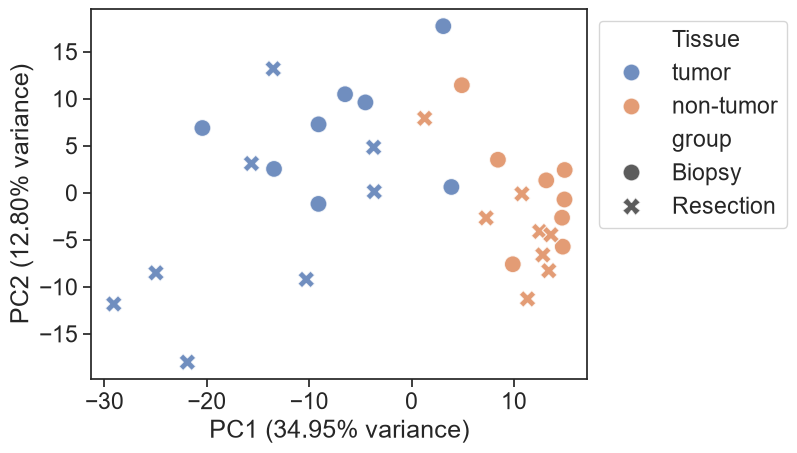

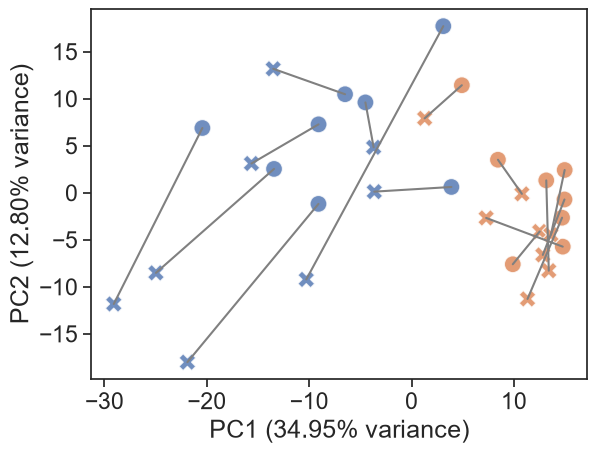

In [181]:
projections = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(projections, columns=[f'PC{x}' for x in range(1,11)], index=df_all_pca.columns)
df_pca['group'] = metadata.Sample_type
df_pca['Tissue'] = metadata.Tissue
df_pca['sex'] = metadata.Sex
df_pca['patient_id'] = metadata.patient_id.astype(str)

for col in ["nontumor", "tumor"]:
    df_pca[col] = metadata[col]

    fig, ax = plt.subplots()
    g = sns.scatterplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2', hue='Tissue', style='group',
                        ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
    j = sns.scatterplot(df_pca[df_pca.Tissue == 'tumor'].dropna(), x='PC1', y='PC2', hue_norm=(0,100),
                        hue=col, style='group', ax=ax, s=150, alpha=0.8, palette='crest')
    k = sns.scatterplot(df_pca[(df_pca.Tissue == 'tumor') & (df_pca[col].isna())], x='PC1', y='PC2',c=sns.color_palette(['gray']),
                        ax=ax, s=150, alpha=0.8)
    h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2', 
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                     hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
    #plt.legend([],[], frameon=False)
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.savefig(f'figures/PCA_all_{col}.pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

    

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig('figures/PCA_all.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='Tissue', style='group',
                    ax=ax, s=150, alpha=0.8, hue_order=['tumor', 'non-tumor'])
h = sns.lineplot(df_pca[df_pca.Tissue == 'tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
i = sns.lineplot(df_pca[df_pca.Tissue == 'non-tumor'], x='PC1', y='PC2',
                 hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('figures/PCA_all_pat.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

## 12. Non-tumor PCA and paired-distance analysis

Visualize non-tumor sample structure and quantify paired biopsy/resection displacement in the first 10 PCs.

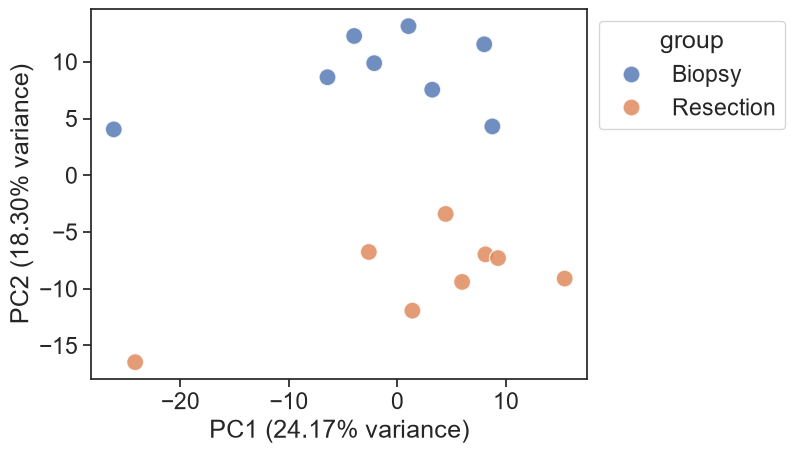

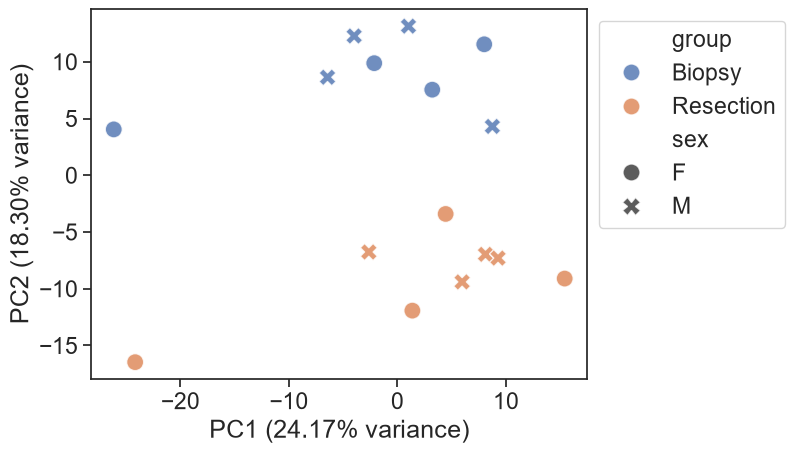

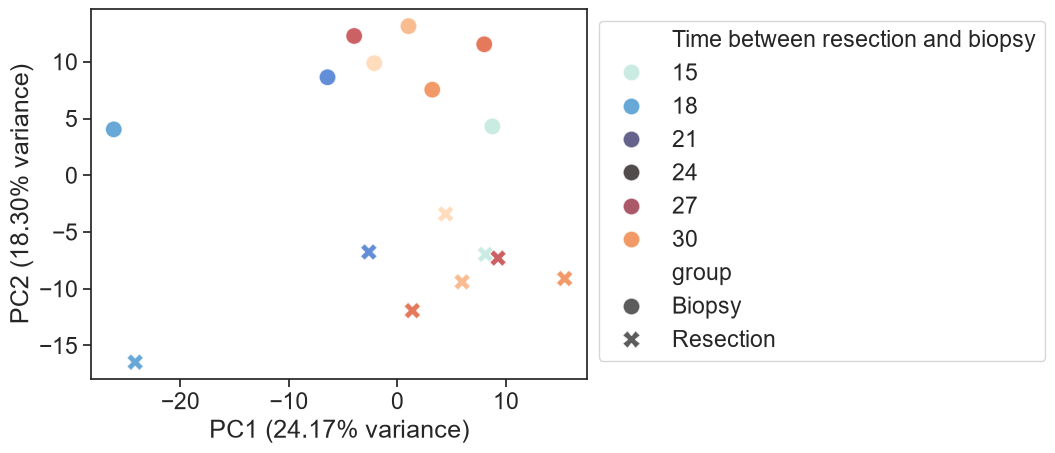

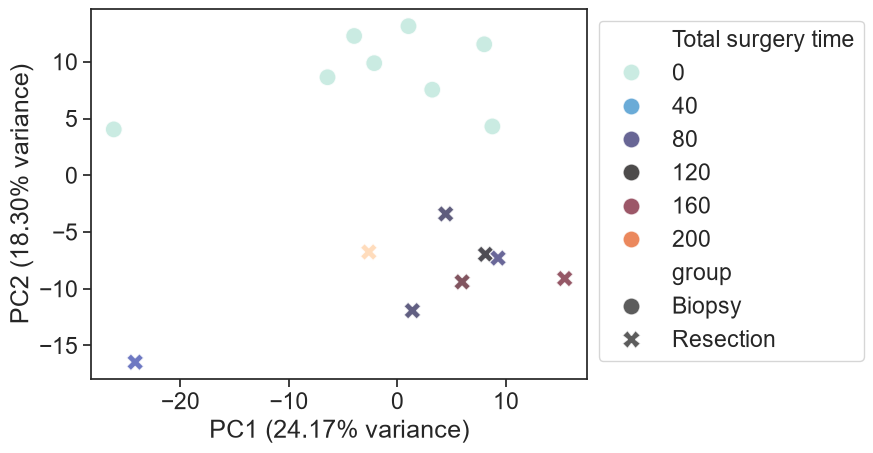

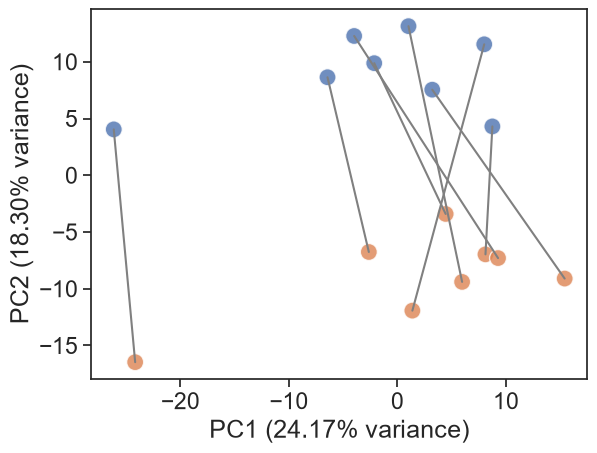

In [182]:
# PCA

used_cols = [x for x in df_liver_imputed.columns if x.startswith('non-tumor')]

# Most variable proteins
df_liver_pca = df_liver_imputed.loc[:,used_cols].copy()
df_liver_pca['abs_std'] = df_liver_pca.std(axis=1)
df_liver_pca = df_liver_pca.sort_values('abs_std', ascending=False)
df_liver_pca = df_liver_pca.iloc[:500,:-1]

scaled = scaler.fit_transform(df_liver_pca.T)

pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=[f'PC{x}' for x in range (1,11)])
df_pca['group'] = metadata_liver.Sample_type
df_pca['sex'] = metadata_liver.Sex
df_pca['patient_id'] = metadata_liver.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_liver['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_liver['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_{today}.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_sex_{today}.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_timeBvR_{today}.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_liver_surgerytime_{today}.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_liver_pat_{today}.pdf', bbox_inches='tight', dpi=300)

In [183]:
def paired_distance_magnitude(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates paired biopsy-to-resection distances and patient centroids
    in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    pair_rows = []
    centroid_rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        b_vec = scores.loc[b, pc_cols].values.astype(float)
        r_vec = scores.loc[r, pc_cols].values.astype(float)

        diff = r_vec - b_vec
        dist = np.linalg.norm(diff)

        centroid = (b_vec + r_vec) / 2

        row = {
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "paired_distance": dist,
        }

        for pc, value in zip(pc_cols, diff):
            row[f"{pc}_resection_minus_biopsy"] = value

        pair_rows.append(row)

        centroid_rows.append(
            pd.Series(centroid, index=pc_cols, name=patient)
        )

    paired_distances = pd.DataFrame(pair_rows)
    patient_centroids = pd.DataFrame(centroid_rows)

    return paired_distances, patient_centroids

def exhaustive_patient_blocked_collection_test(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Exact patient-blocked permutation test for paired Biopsy/Resection PCA scores.
    Enumerates all 2^n within-patient label swaps.

    Suitable when n_pairs is modest, e.g. <= 20.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    keep_samples = []
    patients_ordered = []

    for patient, m in meta.groupby(patient_col):
        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) == 1 and len(resection_samples) == 1:
            keep_samples.extend([biopsy_samples[0], resection_samples[0]])
            patients_ordered.append(patient)

    meta = meta.loc[keep_samples].copy()
    Y = scores.loc[keep_samples, pc_cols].values

    patient_dummies = pd.get_dummies(meta[patient_col], drop_first=False)
    X_patient = patient_dummies.values.astype(float)

    collection_observed = (
        meta[sample_type_col].values == resection_label
    ).astype(float).reshape(-1, 1)

    def rss_multivariate_lm(Y, X):
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        resid = Y - X @ beta
        rss = np.sum(resid ** 2)
        rank = np.linalg.matrix_rank(X)
        df_resid = Y.shape[0] - rank
        return rss, df_resid, rank

    rss_patient, df_patient, rank_patient = rss_multivariate_lm(Y, X_patient)

    X_full_observed = np.column_stack([X_patient, collection_observed])
    rss_full_obs, df_full, rank_full = rss_multivariate_lm(Y, X_full_observed)

    ss_collection_obs = rss_patient - rss_full_obs
    partial_R2_obs = ss_collection_obs / rss_patient

    n_pairs = len(patients_ordered)

    perm_R2 = []

    # Precompute sample indices for each patient
    patient_to_indices = {
        patient: np.where(meta[patient_col].values == patient)[0]
        for patient in patients_ordered
    }

    for swap_pattern in itertools.product([0, 1], repeat=n_pairs):

        collection_perm = collection_observed.copy()

        for patient, swap in zip(patients_ordered, swap_pattern):
            if swap == 1:
                idx = patient_to_indices[patient]
                collection_perm[idx] = 1 - collection_perm[idx]

        X_perm = np.column_stack([X_patient, collection_perm])
        rss_perm_full, _, _ = rss_multivariate_lm(Y, X_perm)

        ss_perm_collection = rss_patient - rss_perm_full
        perm_R2.append(ss_perm_collection / rss_patient)

    perm_R2 = np.array(perm_R2)

    exact_p = np.mean(perm_R2 >= partial_R2_obs - 1e-12)

    result = {
        "n_pairs": n_pairs,
        "n_samples": meta.shape[0],
        "n_pcs": len(pc_cols),
        "observed_partial_R2": partial_R2_obs,
        "observed_partial_R2_percent": 100 * partial_R2_obs,
        "exact_permutation_p_value": exact_p,
        "n_total_permutations": len(perm_R2),
        "n_permutations_ge_observed": int(np.sum(perm_R2 >= partial_R2_obs - 1e-12)),
        "max_permuted_partial_R2": np.max(perm_R2),
        "max_permuted_partial_R2_percent": 100 * np.max(perm_R2),
    }

    return result, perm_R2

In [184]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,D,non-tumor_Biopsy_D,non-tumor_Resection_D,10,32.134448,-6.620742,-23.468242,-6.022657,-11.163355,-2.087242,-6.147841,6.495023,4.251020,-6.970649,-11.231130
1,E,non-tumor_Biopsy_E,non-tumor_Resection_E,10,25.809090,4.940925,-22.534353,-5.437695,1.498377,-2.695970,5.340183,3.173793,-6.724051,-3.235970,-0.736554
2,I,non-tumor_Biopsy_I,non-tumor_Resection_I,10,21.170235,12.197618,-16.644309,1.813438,3.162955,-0.021866,0.386830,-1.199398,1.964192,1.670352,0.913400
3,L,non-tumor_Biopsy_L,non-tumor_Resection_L,10,23.770193,1.972151,-20.510854,-8.427609,-1.340833,-0.856310,1.290922,2.098835,-6.300356,-4.522314,0.815149
4,N,non-tumor_Biopsy_N,non-tumor_Resection_N,10,29.625132,-0.636411,-11.272468,9.502345,-8.846971,15.477840,-6.579659,7.162115,12.772131,9.178266,-0.303651
5,O,non-tumor_Biopsy_O,non-tumor_Resection_O,10,26.872768,13.255522,-19.570718,7.838343,-1.118167,-1.565490,3.373895,-6.170922,-2.759784,4.701477,4.370282
6,Q,non-tumor_Biopsy_Q,non-tumor_Resection_Q,10,16.853807,6.578858,-13.284991,3.558079,1.413832,-3.527219,3.380362,-3.405754,-0.723419,3.684985,-0.223346
7,T,non-tumor_Biopsy_T,non-tumor_Resection_T,10,23.917879,3.807072,-15.396751,10.619770,-1.819165,4.039424,3.850466,-6.526893,1.838938,-3.035081,10.866716


In [185]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,8,10,24.863484,25.019194,22.322127,1.113849,75.0


In [186]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,D,non-tumor_Biopsy_D,non-tumor_Resection_D,10,32.134448,-6.620742,-23.468242,-6.022657,-11.163355,-2.087242,-6.147841,6.495023,4.251020,-6.970649,-11.231130,78.571429,1.439578
1,E,non-tumor_Biopsy_E,non-tumor_Resection_E,10,25.809090,4.940925,-22.534353,-5.437695,1.498377,-2.695970,5.340183,3.173793,-6.724051,-3.235970,-0.736554,75.000000,1.156211
2,I,non-tumor_Biopsy_I,non-tumor_Resection_I,10,21.170235,12.197618,-16.644309,1.813438,3.162955,-0.021866,0.386830,-1.199398,1.964192,1.670352,0.913400,28.571429,0.948397
3,L,non-tumor_Biopsy_L,non-tumor_Resection_L,10,23.770193,1.972151,-20.510854,-8.427609,-1.340833,-0.856310,1.290922,2.098835,-6.300356,-4.522314,0.815149,71.428571,1.064871
4,N,non-tumor_Biopsy_N,non-tumor_Resection_N,10,29.625132,-0.636411,-11.272468,9.502345,-8.846971,15.477840,-6.579659,7.162115,12.772131,9.178266,-0.303651,78.571429,1.327164
5,O,non-tumor_Biopsy_O,non-tumor_Resection_O,10,26.872768,13.255522,-19.570718,7.838343,-1.118167,-1.565490,3.373895,-6.170922,-2.759784,4.701477,4.370282,75.000000,1.203862
6,Q,non-tumor_Biopsy_Q,non-tumor_Resection_Q,10,16.853807,6.578858,-13.284991,3.558079,1.413832,-3.527219,3.380362,-3.405754,-0.723419,3.684985,-0.223346,0.000000,0.755027
7,T,non-tumor_Biopsy_T,non-tumor_Resection_T,10,23.917879,3.807072,-15.396751,10.619770,-1.819165,4.039424,3.850466,-6.526893,1.838938,-3.035081,10.866716,71.428571,1.071487


In [187]:
diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})

direction_summary

,n_pairs,n_pcs,mean_vector_length,mean_individual_paired_distance,directional_coherence
0,8,10,18.655979,25.019194,0.745667


In [188]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [189]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [190]:
plot_df_norm.mean(numeric_only=True)

paired_distance      25.019194
relative_distance     1.120825
dtype: float64

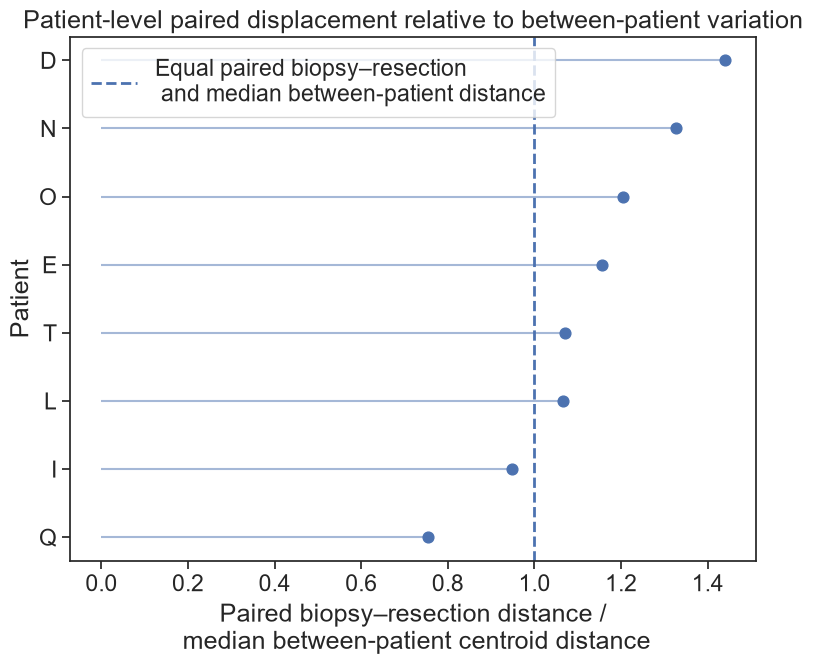

In [191]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig(f'Distance_Liver_proteome_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [192]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_liver,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

joint_test_result

{'n_pairs': 8,
 'n_samples': 16,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.5387866320032185),
 'observed_partial_R2_percent': np.float64(53.87866320032185),
 'exact_permutation_p_value': np.float64(0.0078125),
 'n_total_permutations': 256,
 'n_permutations_ge_observed': 2,
 'max_permuted_partial_R2': np.float64(0.5387866320032186),
 'max_permuted_partial_R2_percent': np.float64(53.87866320032187)}

In [193]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv(f'Permutation_proteome_liver_{today}.csv')
test_out

,0
n_pairs,8.000000
n_samples,16.000000
n_pcs,10.000000
observed_partial_R2,0.538787
observed_partial_R2_percent,53.878663
exact_permutation_p_value,0.007812
n_total_permutations,256.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.538787
max_permuted_partial_R2_percent,53.878663


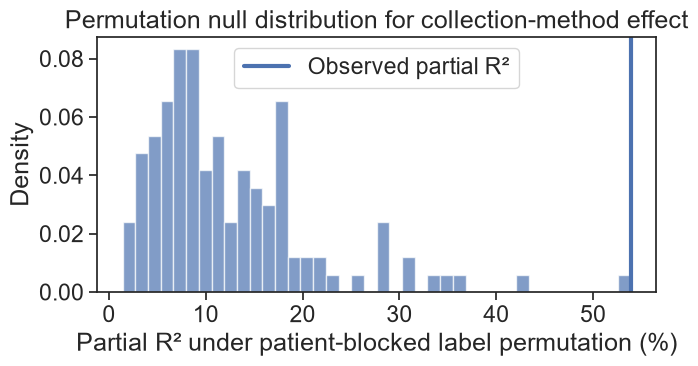

In [194]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig(f'Permutation_Liver_proteome_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [195]:
def r2(x, y, ax=None, **kws):
    ax = ax or plt.gca()
    mask = ~np.isnan(x) & ~np.isnan(y)
    slope, intercept, r_value, p_value, std_err = linregress(x[mask], y[mask])
    ax.annotate(f'$r^2 = {r_value ** 2:.2f}$\nEq: ${slope:.2f}x{intercept:+.2f}$\np: ${p_value :.2E}$',
                xy=(.05, .95), xycoords=ax.transAxes, fontsize=8,
                color='darkred', backgroundcolor='#FFFFFF99', ha='left', va='top')

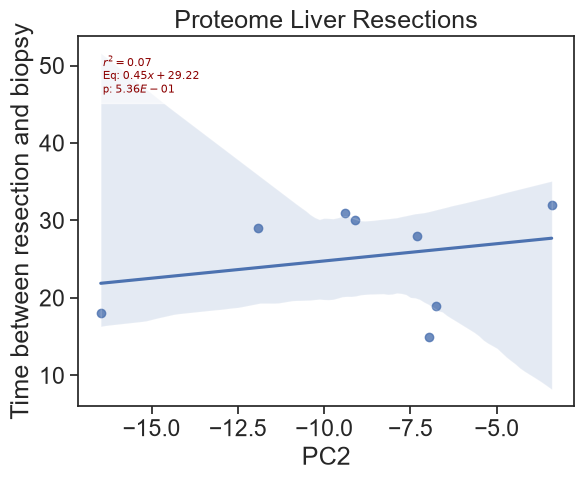

In [196]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Liver Resections')


plt.savefig(f'figures/corr_pc2_time_b_to_r_{today}.pdf', dpi=300, bbox_inches='tight')

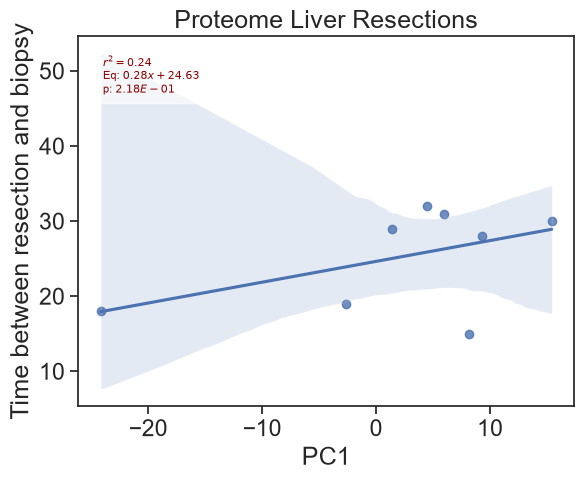

In [197]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Liver Resections')


plt.savefig(f'figures/corr_pc1_time_b_to_r_{today}.pdf', dpi=300, bbox_inches='tight')

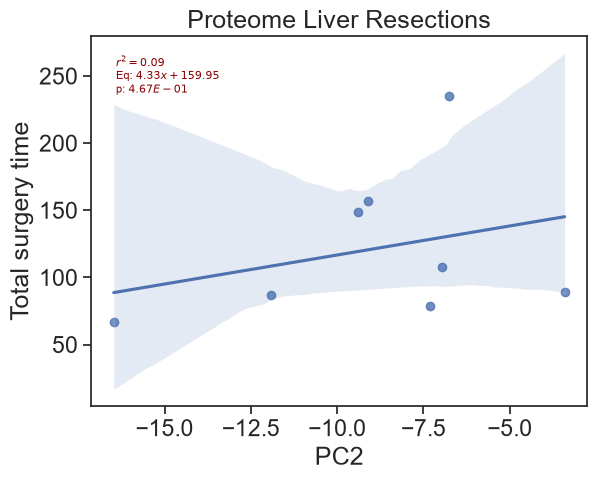

In [198]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Proteome Liver Resections')

plt.savefig(f'figures/corr_pc2_time_surgery_{today}.pdf', dpi=300, bbox_inches='tight')

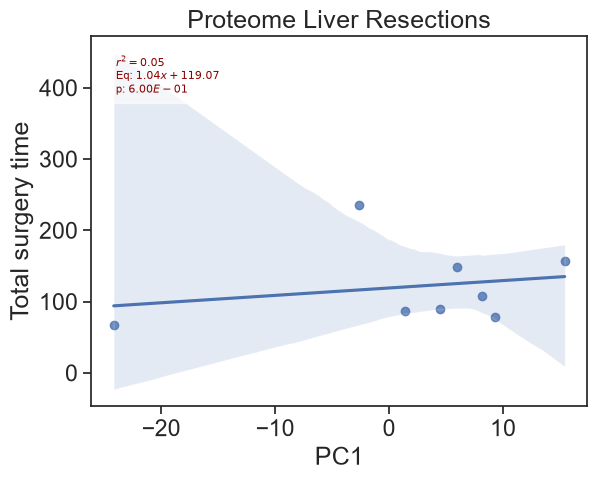

In [199]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Proteome Liver Resections')

plt.savefig(f'figures/corr_pc1_time_surgery_{today}.pdf', dpi=300, bbox_inches='tight')

## 13. HCC PCA and paired-distance analysis

Repeat PCA, distance benchmarking, and patient-blocked permutation testing in HCC.

In [200]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.255272,22.353943,23.569225,23.161396,24.026705,22.659174,23.613865,22.270475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.967411,22.219536,22.301674,22.981184,21.408100,22.423550,22.785063,21.406275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.648235,21.949207,22.197075,22.566017,22.523945,23.312183,23.249437,21.974596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.577009,22.293673,22.284140,22.376797,23.050961,22.686665,22.996695,22.447262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.140676,24.282225,26.508230,25.480110,25.168591,23.044794,24.995989,23.947323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.881674,23.141455,23.304840,24.875446,21.337704,22.701815,23.112858,22.996946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.742456,17.001955,17.750624,18.114475,17.346569,18.056957,17.171499,17.787691,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.265703,17.282082,18.008360,17.719534,17.202330,16.964922,16.974493,17.633694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.387304,16.295835,16.375607,16.317015,16.930548,16.818823,17.347580,16.177885,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,16.143217,15.985530,15.229109,16.047270,15.980369,16.047676,16.039684,15.806023,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


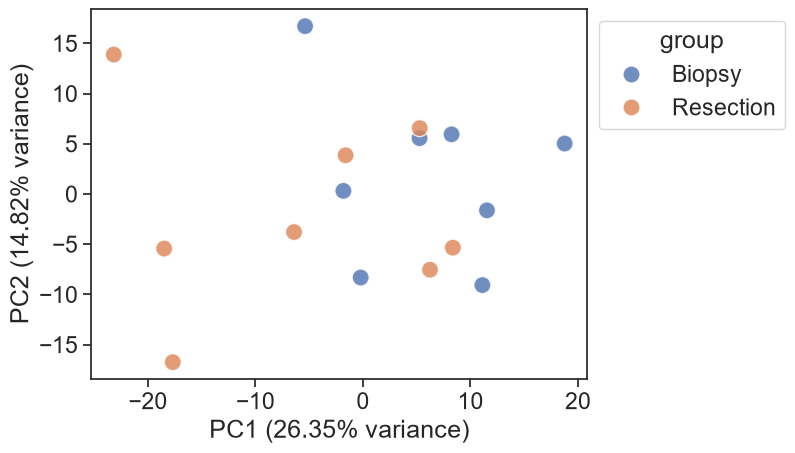

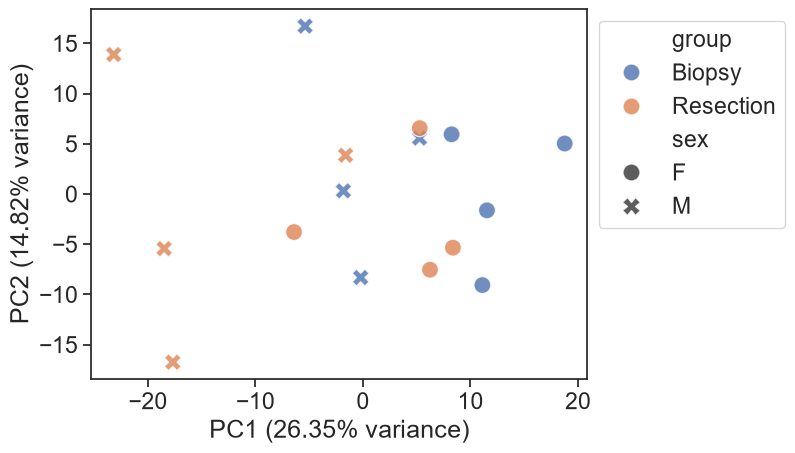

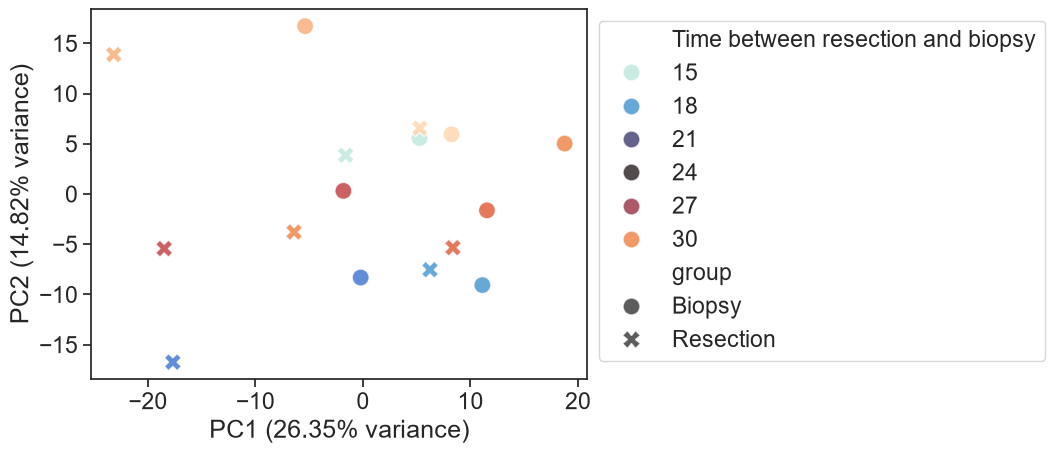

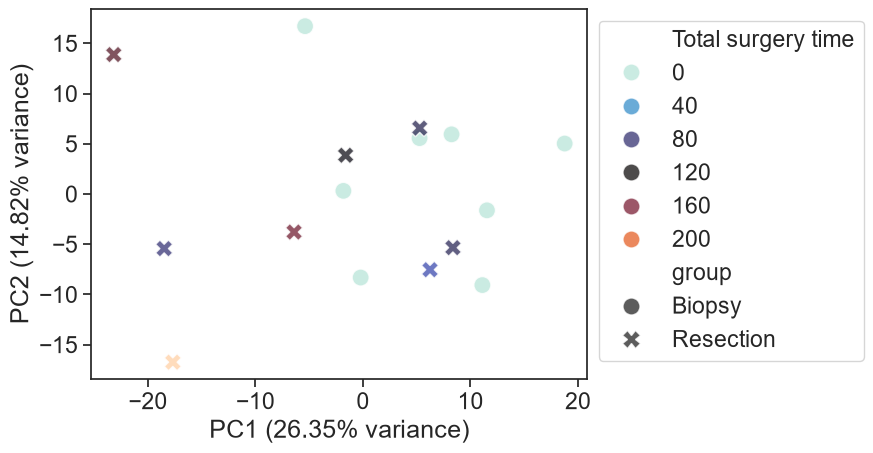

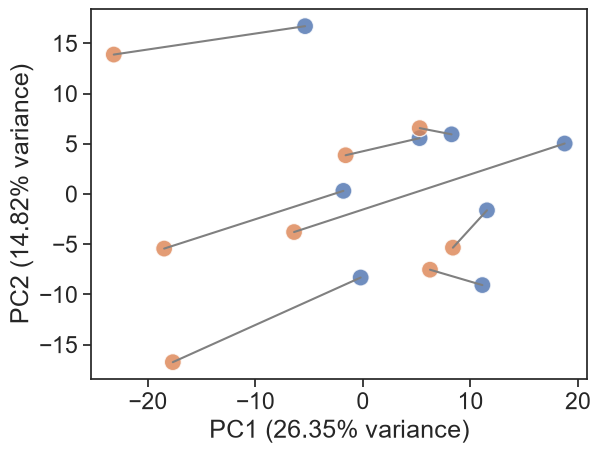

In [201]:
# HCC

used_cols = [x for x in df_hcc_imputed.columns if x.startswith('tumor')]

# Most variable proteins
df_hcc_pca = df_hcc_imputed.loc[:,used_cols].copy()
df_hcc_pca['abs_std'] = df_hcc_pca.std(axis=1)
df_hcc_pca = df_hcc_pca.sort_values('abs_std', ascending=False)
df_hcc_pca = df_hcc_pca.iloc[:500,:-1]

# PCA
scaled = scaler.fit_transform(df_hcc_pca.T)
pca_data = pca.fit_transform(scaled)

df_pca = pd.DataFrame(pca_data, index=used_cols, columns=[f'PC{x}' for x in range(1,11)])
df_pca['group'] = metadata_hcc.Sample_type
df_pca['sex'] = metadata_hcc.Sex
df_pca['patient_id'] = metadata_hcc.patient_id.astype(str)
df_pca['Time between resection and biopsy'] = metadata_hcc['Time between resection and biopsy']
df_pca['Total surgery time'] = metadata_hcc['Total surgery time']

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_{today}.pdf', bbox_inches='tight', dpi=300)

#plt.show()

# Sex
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='sex',
                    hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_sex_{today}.pdf', bbox_inches='tight', dpi=300)

# Time between B and R
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Time between resection and biopsy', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_timeBvR_{today}.pdf', bbox_inches='tight', dpi=300)

# Surgery time
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2',style='group',
                    hue='Total surgery time', ax=ax, s=150, alpha=0.8, palette='icefire')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.savefig(f'figures/PCA_hcc_surgerytime_{today}.pdf', bbox_inches='tight', dpi=300)

# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca, x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig(f'figures/PCA_hcc_pat_{today}.pdf', bbox_inches='tight', dpi=300)

In [202]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,D,tumor_Biopsy_D,tumor_Resection_D,10,9.307124,-3.167341,-3.716685,-1.436494,-0.788498,3.996454,3.776183,2.477777,-1.680176,4.556436,-0.369919
1,E,tumor_Biopsy_E,tumor_Resection_E,10,24.224577,-17.792564,-2.827441,-9.061306,2.929864,0.258299,0.790790,2.845802,5.548870,2.063805,11.301730
2,I,tumor_Biopsy_I,tumor_Resection_I,10,33.273984,-25.165679,-8.812877,-16.543282,-2.077822,0.257836,-6.191465,8.321466,0.056236,2.721038,1.768484
3,L,tumor_Biopsy_L,tumor_Resection_L,10,13.436950,-4.869267,1.531745,-6.962273,-3.626239,5.895561,4.777264,2.395643,-2.144709,1.101178,4.872513
4,N,tumor_Biopsy_N,tumor_Resection_N,10,12.055607,-6.876571,-1.704023,-2.598167,0.680135,6.843994,1.262569,3.429469,2.546801,2.767356,3.686954
5,O,tumor_Biopsy_O,tumor_Resection_O,10,32.220179,-16.668235,-5.747542,-12.624658,-12.209281,7.619498,6.752764,0.944522,-9.012976,-13.307775,-7.479828
6,Q,tumor_Biopsy_Q,tumor_Resection_Q,10,17.016767,-2.960450,0.618196,-5.994967,-2.750424,7.992076,10.374781,-1.172385,-3.924117,0.572106,6.950514
7,T,tumor_Biopsy_T,tumor_Resection_T,10,31.925457,-17.468688,-8.427308,-12.913650,2.221789,1.213229,5.853551,-9.542861,12.083446,9.571186,-10.341279


In [203]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,8,10,20.620672,21.682581,27.286844,0.7557,14.285714


In [204]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,patient_id,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,D,tumor_Biopsy_D,tumor_Resection_D,10,9.307124,-3.167341,-3.716685,-1.436494,-0.788498,3.996454,3.776183,2.477777,-1.680176,4.556436,-0.369919,0.000000,0.341085
1,E,tumor_Biopsy_E,tumor_Resection_E,10,24.224577,-17.792564,-2.827441,-9.061306,2.929864,0.258299,0.790790,2.845802,5.548870,2.063805,11.301730,32.142857,0.887775
2,I,tumor_Biopsy_I,tumor_Resection_I,10,33.273984,-25.165679,-8.812877,-16.543282,-2.077822,0.257836,-6.191465,8.321466,0.056236,2.721038,1.768484,92.857143,1.219415
3,L,tumor_Biopsy_L,tumor_Resection_L,10,13.436950,-4.869267,1.531745,-6.962273,-3.626239,5.895561,4.777264,2.395643,-2.144709,1.101178,4.872513,0.000000,0.492433
4,N,tumor_Biopsy_N,tumor_Resection_N,10,12.055607,-6.876571,-1.704023,-2.598167,0.680135,6.843994,1.262569,3.429469,2.546801,2.767356,3.686954,0.000000,0.441810
5,O,tumor_Biopsy_O,tumor_Resection_O,10,32.220179,-16.668235,-5.747542,-12.624658,-12.209281,7.619498,6.752764,0.944522,-9.012976,-13.307775,-7.479828,92.857143,1.180795
6,Q,tumor_Biopsy_Q,tumor_Resection_Q,10,17.016767,-2.960450,0.618196,-5.994967,-2.750424,7.992076,10.374781,-1.172385,-3.924117,0.572106,6.950514,0.000000,0.623625
7,T,tumor_Biopsy_T,tumor_Resection_T,10,31.925457,-17.468688,-8.427308,-12.913650,2.221789,1.213229,5.853551,-9.542861,12.083446,9.571186,-10.341279,92.857143,1.169994


In [205]:
diff_cols = [f"{pc}_resection_minus_biopsy" for pc in pc_cols]

diff_matrix = paired_distances[diff_cols].values

mean_displacement_vector = diff_matrix.mean(axis=0)

mean_vector_length = np.linalg.norm(mean_displacement_vector)
mean_individual_distance = np.mean(
    np.linalg.norm(diff_matrix, axis=1)
)

directional_coherence = mean_vector_length / mean_individual_distance

direction_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "mean_vector_length": [mean_vector_length],
    "mean_individual_paired_distance": [mean_individual_distance],
    "directional_coherence": [directional_coherence],
})

direction_summary

,n_pairs,n_pcs,mean_vector_length,mean_individual_paired_distance,directional_coherence
0,8,10,16.287554,21.682581,0.751182


In [206]:
patient_col = 'patient_id'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [207]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [208]:
plot_df_norm.mean(numeric_only=True)

paired_distance      21.682581
relative_distance     0.794617
dtype: float64

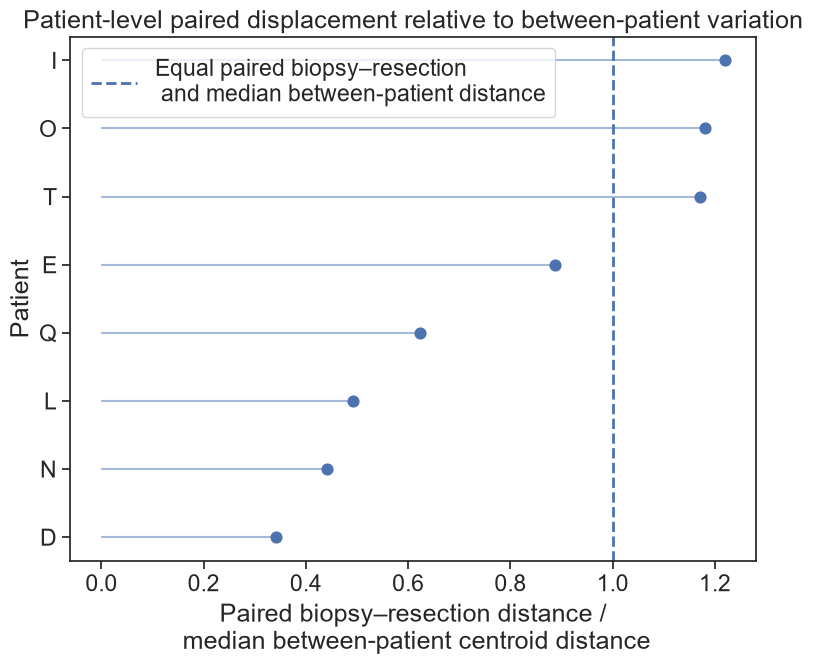

In [209]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig(f'Distance_PCA_proteome_HCC_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [210]:
joint_test_result, perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=df_pca,
    meta=metadata_hcc,
    patient_col='patient_id',
    sample_type_col='Sample_type',
    biopsy_label='Biopsy',
    resection_label='Resection',
    pc_cols=pc_cols,
)

joint_test_result

{'n_pairs': 8,
 'n_samples': 16,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.47654689571179865),
 'observed_partial_R2_percent': np.float64(47.654689571179865),
 'exact_permutation_p_value': np.float64(0.0078125),
 'n_total_permutations': 256,
 'n_permutations_ge_observed': 2,
 'max_permuted_partial_R2': np.float64(0.47654689571179865),
 'max_permuted_partial_R2_percent': np.float64(47.654689571179865)}

In [211]:
test_out = pd.DataFrame().from_dict(joint_test_result, orient='index')
test_out.to_csv(f'Permutation_proteome_hcc_{today}.csv')
test_out

,0
n_pairs,8.000000
n_samples,16.000000
n_pcs,10.000000
observed_partial_R2,0.476547
observed_partial_R2_percent,47.654690
exact_permutation_p_value,0.007812
n_total_permutations,256.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.476547
max_permuted_partial_R2_percent,47.654690


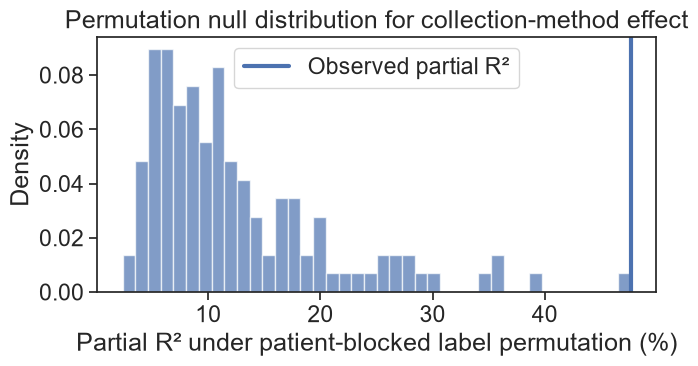

In [212]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = joint_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig(f'Permutation_HCC_proteome_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 14. Tumor-content sensitivity analysis

Assess whether HCC PCA displacement is associated with paired change in tumor content.

In [213]:
from scipy.stats import spearmanr

tumor_content_col = "tumor"  # change if needed
patient_col = "patient_id"
n_perm = 16384 #2**15
random_seed = 42

diff_cols = [
    f"{pc}_resection_minus_biopsy"
    for pc in pc_cols
]

# ------------------------------------------------------------------
# Assemble paired PCA and tumour-content changes
# ------------------------------------------------------------------

tumor_content = pd.to_numeric(
    metadata_hcc[tumor_content_col],
    errors="coerce",
)

analysis_df = paired_distances.copy()

analysis_df["biopsy_tumor_content"] = (
    analysis_df["biopsy_sample"].map(tumor_content)
)
analysis_df["resection_tumor_content"] = (
    analysis_df["resection_sample"].map(tumor_content)
)

# Signed change is needed for multivariate regression
analysis_df["tumor_content_delta"] = (
    analysis_df["resection_tumor_content"]
    - analysis_df["biopsy_tumor_content"]
)

# Absolute change is used for the magnitude correlation
analysis_df["tumor_content_change"] = (
    analysis_df["tumor_content_delta"].abs()
)

analysis_df["relative_pca_distance"] = (
    analysis_df["paired_distance"]
    / median_between_patient_distance
)

analysis_df = analysis_df.dropna(
    subset=[
        "tumor_content_delta",
        "relative_pca_distance",
        *diff_cols,
    ]
).copy()

if len(analysis_df) < 3:
    raise ValueError("At least three complete pairs are required.")

if analysis_df["tumor_content_delta"].nunique() < 2:
    raise ValueError("Tumour-content change has no variation.")

print(f"Complete pairs included: {len(analysis_df)}")

Complete pairs included: 7


In [214]:
spearman_rho, spearman_p = spearmanr(
    analysis_df["tumor_content_change"],
    analysis_df["relative_pca_distance"],
)

print(f"Spearman rho: {spearman_rho:.3f}")
print(f"Spearman p-value: {spearman_p:.4g}")

Spearman rho: -0.143
Spearman p-value: 0.7599


In [215]:
delta_tumor = analysis_df["tumor_content_delta"].to_numpy(dtype=float)
delta_pca = analysis_df[diff_cols].to_numpy(dtype=float)

# Multivariate OLS: one regression fitted jointly across all PC outcomes
X = np.column_stack([
    np.ones(len(delta_tumor)),
    delta_tumor,
])

coefficients, _, _, _ = np.linalg.lstsq(
    X,
    delta_pca,
    rcond=None,
)

sample_type_vector = coefficients[0]
tumor_content_slope = coefficients[1]

fitted_delta_pca = X @ coefficients
residual_delta_pca = delta_pca - fitted_delta_pca

# Multivariate R² across all included PCs
centered_delta_pca = delta_pca - delta_pca.mean(axis=0)

total_ss = np.sum(centered_delta_pca**2)
residual_ss = np.sum(residual_delta_pca**2)

multivariate_r2 = 1 - residual_ss / total_ss

# PCA-space effect sizes
sample_type_distance_adjusted = np.linalg.norm(
    sample_type_vector
)

tumor_distance_per_20_percent = np.linalg.norm(
    tumor_content_slope * 20
)

sample_type_relative_distance = (
    sample_type_distance_adjusted
    / median_between_patient_distance
)

tumor_relative_distance_per_20_percent = (
    tumor_distance_per_20_percent
    / median_between_patient_distance
)

In [216]:
def calculate_multivariate_r2(x, y):
    """R² for y ~ intercept + x, with multivariate y."""
    x_centered = x - x.mean()
    y_centered = y - y.mean(axis=0)

    x_ss = x_centered @ x_centered
    y_ss = np.sum(y_centered**2)

    slopes = (x_centered @ y_centered) / x_ss
    fitted_centered = np.outer(x_centered, slopes)

    return np.sum(fitted_centered**2) / y_ss


rng = np.random.default_rng(random_seed)
permuted_r2 = np.empty(n_perm)

for i in range(n_perm):
    permuted_delta = rng.permutation(delta_tumor)
    permuted_r2[i] = calculate_multivariate_r2(
        permuted_delta,
        delta_pca,
    )

multivariate_permutation_p = (
    1 + np.count_nonzero(permuted_r2 >= multivariate_r2)
) / (n_perm + 1)

In [217]:
multivariate_summary = pd.DataFrame({
    "n_pairs": [len(analysis_df)],
    "n_pcs": [len(pc_cols)],
    "multivariate_r_squared": [multivariate_r2],
    "permutation_p_value": [multivariate_permutation_p],
    "adjusted_sample_type_distance": [
        sample_type_distance_adjusted
    ],
    "adjusted_sample_type_relative_distance": [
        sample_type_relative_distance
    ],
    "tumor_content_distance_per_20_percentage_points": [
        tumor_distance_per_20_percent
    ],
    "tumor_content_relative_distance_per_20_percentage_points": [
        tumor_relative_distance_per_20_percent
    ],
})

coefficient_table = pd.DataFrame({
    "PC": pc_cols,
    "adjusted_biopsy_to_resection_effect": sample_type_vector,
    "effect_per_20_percentage_point_tumor_change":
        tumor_content_slope * 20,
})

display(multivariate_summary)
display(coefficient_table)

,n_pairs,n_pcs,multivariate_r_squared,permutation_p_value,adjusted_sample_type_distance,adjusted_sample_type_relative_distance,tumor_content_distance_per_20_percentage_points,tumor_content_relative_distance_per_20_percentage_points
0,7,10,0.057907,0.952151,15.22211,0.557855,3.830796,0.14039


,PC,adjusted_biopsy_to_resection_effect,effect_per_20_percentage_point_tumor_change
0,PC1,-10.759887,-2.126004
1,PC2,-2.317257,-1.717622
2,PC3,-7.739819,-1.014152
3,PC4,-2.034201,0.174440
4,PC5,5.264772,-1.371788
5,PC6,2.099357,0.296326
6,PC7,2.704819,-1.026996
7,PC8,0.524101,0.475004
8,PC9,1.072466,0.250441
9,PC10,2.378858,-1.683230


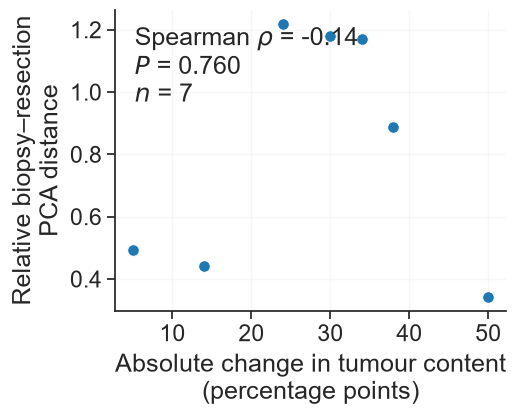

In [218]:
x = analysis_df["tumor_content_change"]
y = analysis_df["relative_pca_distance"]

rho, p_value = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(5.5, 4.5))

ax.scatter(
    x,
    y,
    s=70,
    color="tab:blue",
    edgecolor="white",
    linewidth=0.7,
)

ax.text(
    0.05,
    0.95,
    (
        f"Spearman $\\rho$ = {rho:.2f}\n"
        f"$P$ = {p_value:.3f}\n"
        f"$n$ = {len(analysis_df)}"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
)

ax.set_xlabel(
    "Absolute change in tumour content\n"
    "(percentage points)"
)
ax.set_ylabel(
    "Relative biopsy–resection\nPCA distance"
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(alpha=0.15)
fig.tight_layout()

fig.savefig(
    "Tumor_content_vs_PCA_distance_simple.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

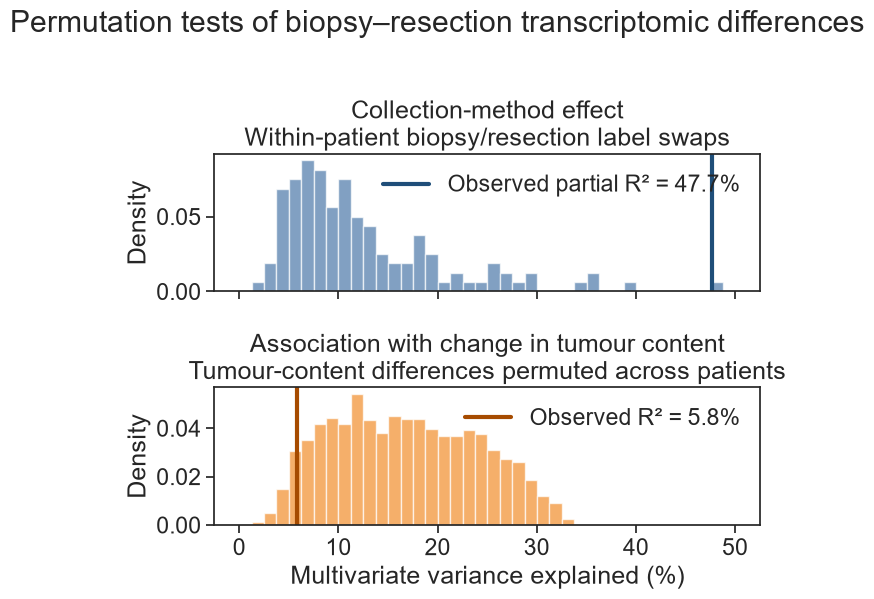

In [219]:
collection_null = perm_R2 * 100
tissue_null = permuted_r2 * 100

collection_observed = (
    joint_test_result["observed_partial_R2"] * 100
)
tissue_observed = multivariate_r2 * 100

# Common range and bin edges make visual comparison easier
x_max = max(
    collection_null.max(),
    tissue_null.max(),
    collection_observed,
    tissue_observed,
)

bins = np.linspace(0, x_max * 1.05, 41)

fig, axes = plt.subplots(
    2, 1,
    figsize=(7, 6),
    sharex=True,
)

# Collection-method test
axes[0].hist(
    collection_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#4C78A8",
)

axes[0].axvline(
    collection_observed,
    color="#1F4E79",
    linewidth=3,
    label=f"Observed partial R² = {collection_observed:.1f}%",
)

axes[0].set_ylabel("Density")
axes[0].set_title(
    "Collection-method effect\n"
    "Within-patient biopsy/resection label swaps"
)
axes[0].legend(frameon=False)

# Tissue-composition test
axes[1].hist(
    tissue_null,
    bins=bins,
    density=True,
    alpha=0.7,
    color="#F28E2B",
)

axes[1].axvline(
    tissue_observed,
    color="#A64B00",
    linewidth=3,
    label=f"Observed R² = {tissue_observed:.1f}%",
)

axes[1].set_xlabel("Multivariate variance explained (%)")
axes[1].set_ylabel("Density")
axes[1].set_title(
    "Association with change in tumour content\n"
    "Tumour-content differences permuted across patients"
)
axes[1].legend(frameon=False)

fig.suptitle(
    "Permutation tests of biopsy–resection transcriptomic differences",
    y=1.01,
)

plt.tight_layout()
plt.savefig(
    "Permutation_histograms_collection_and_tissue_composition.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

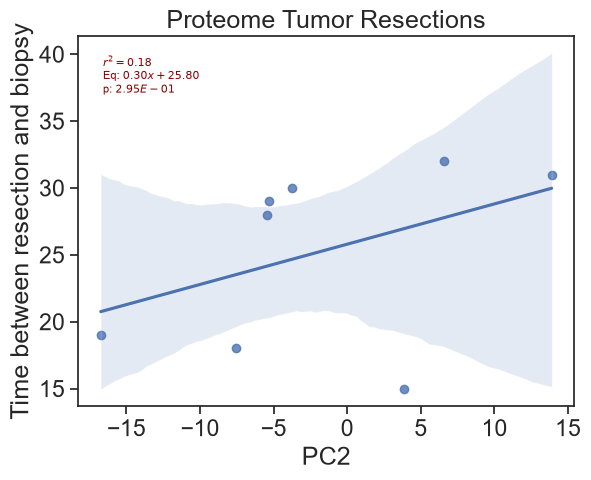

In [586]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Time between resection and biopsy')
r2(df_pca_biop.PC2, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Tumor Resections')


plt.savefig(f'figures/corr_pc2_time_b_to_r_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

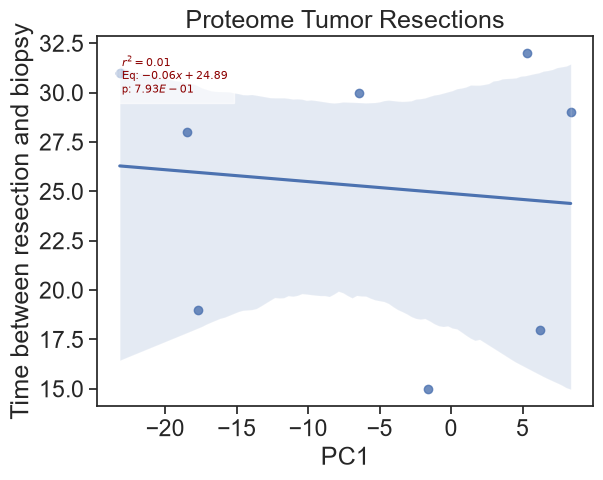

In [587]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Time between resection and biopsy')
r2(df_pca_biop.PC1, df_pca_biop['Time between resection and biopsy'])

plt.title('Proteome Tumor Resections')


plt.savefig(f'figures/corr_pc1_time_b_to_r_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

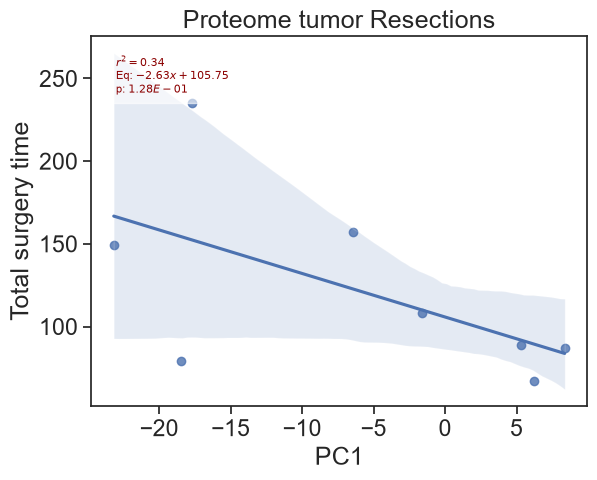

In [588]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC1', y='Total surgery time')
r2(df_pca_biop.PC1, df_pca_biop['Total surgery time'])

plt.title('Proteome tumor Resections')

plt.savefig(f'figures/corr_pc1_time_surgery_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

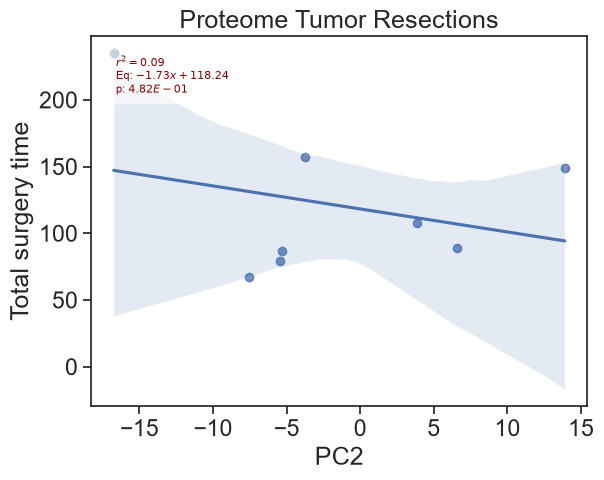

In [589]:
df_pca_biop = df_pca[df_pca.group == 'Resection'].copy()

sns.regplot(df_pca_biop, x='PC2', y='Total surgery time')
r2(df_pca_biop.PC2, df_pca_biop['Total surgery time'])

plt.title('Proteome Tumor Resections')

plt.savefig(f'figures/corr_pc2_time_surgery_tumor_{today}.pdf', dpi=300, bbox_inches='tight')

## 15. Paired t-test helper functions

Define the retained paired t-test, multiple-testing, fold-change, and plotting utilities used in the original analysis.

In [590]:
# Helper functions for calculating p-values, adjusted p-values and fold-changes
from scipy import stats

def students_ttest(df, group_cols, control_cols, index_col=None,
                   group_name="group", control_name="control",
                   paired=False, pairing=None):
    """
    Perform Student's t-test (paired or unpaired) between two groups of samples.

    Parameters:
    - df : pandas.DataFrame
        Features as rows, samples as columns.
    - group_cols : list of str
        Column names of the treatment group.
    - control_cols : list of str
        Column names of the control group.
    - index_col : str or None
        If provided, column to set as index in the result.
    - group_name : str
        Label for the group (used in output column names).
    - control_name : str
        Label for the control (used in output column names).
    - paired : bool
        If True, perform paired t-test (requires `pairing`).
    - pairing : pd.Series or None
        Required if `paired=True`. Index = sample names (columns), values = pairing IDs.

    Returns:
    - df_result : pandas.DataFrame
        Contains t-statistics, p-values, adjusted p-values, and fold changes.
    """
    df_ = df.copy()

    if paired:
        if pairing is None:
            raise ValueError("Pairing metadata must be provided for paired t-test.")
        # Map pair IDs to columns for each group
        group_pairs = pairing.loc[group_cols]
        control_pairs = pairing.loc[control_cols]

        # Find common pair IDs between group and control
        common_pairs = group_pairs[group_pairs.isin(control_pairs.values)].unique()
        if len(common_pairs) == 0:
            raise ValueError("No matching pair IDs found between group and control.")

        # Align columns based on common pair IDs
        group_aligned = [col for col in group_cols if pairing[col] in common_pairs]
        control_aligned = [col for col in control_cols if pairing[col] in common_pairs]
        
        # Map from pair ID to column
        group_map = {pairing[col]: col for col in group_aligned}
        control_map = {pairing[col]: col for col in control_aligned}
        shared_pairs = sorted(set(group_map.keys()) & set(control_map.keys()))

        group_cols_final = [group_map[p] for p in shared_pairs]
        control_cols_final = [control_map[p] for p in shared_pairs]

        if len(group_cols_final) != len(control_cols_final):
            raise ValueError("Aligned paired samples are not the same length.")

        # Paired t-test
        tstats, pvals = stats.ttest_rel(
            df_[group_cols_final].values,
            df_[control_cols_final].values,
            axis=1,
            nan_policy='propagate'
        )
        fold_change = df_[group_cols_final].mean(axis=1) - df_[control_cols_final].mean(axis=1)
    else:
        # Unpaired t-test
        ttest_result = stats.ttest_ind(
            df_[group_cols],
            df_[control_cols],
            axis=1,
            nan_policy='propagate'
        )
        tstats = ttest_result.statistic
        pvals = ttest_result.pvalue
        fold_change = df_[group_cols].mean(axis=1) - df_[control_cols].mean(axis=1)

    label = f"{group_name}vs{control_name}"
    stats_col = f"{label}_tstat"
    pval_col = f"{label}_pval"
    adj_pval_col = f"{label}_adj_pval"
    fc_col = f"{label}_fc"

    # Build result table
    df_[stats_col] = tstats
    df_[pval_col] = pvals
    df_[fc_col] = fold_change

    # Multiple testing correction (Benjamini-Hochberg)
    df_ = df_.sort_values(pval_col).reset_index(names='ID')
    n = df_.shape[0]
    ranks = np.arange(1, n + 1)
    bh_adj = df_[pval_col] * n / ranks
    df_[adj_pval_col] = np.minimum.accumulate(bh_adj[::-1])[::-1].clip(upper=1.0)


    df_.index = df_.ID  # preserve original

    return df_


def power_to_transform(x):
    return 10 ** -x
def neg_log10(x):
    return np.log10(1/x)

In [591]:
df_liver_imputed.columns

Index(['non-tumor_Biopsy_D', 'non-tumor_Biopsy_N', 'non-tumor_Biopsy_O',
       'non-tumor_Biopsy_Q', 'non-tumor_Biopsy_I', 'non-tumor_Biopsy_T',
       'non-tumor_Biopsy_L', 'non-tumor_Biopsy_E',
       'missingindicator_non-tumor_Biopsy_D',
       'missingindicator_non-tumor_Biopsy_N',
       'missingindicator_non-tumor_Biopsy_O',
       'missingindicator_non-tumor_Biopsy_Q',
       'missingindicator_non-tumor_Biopsy_I',
       'missingindicator_non-tumor_Biopsy_T',
       'missingindicator_non-tumor_Biopsy_L',
       'missingindicator_non-tumor_Biopsy_E', 'non-tumor_Resection_D',
       'non-tumor_Resection_N', 'non-tumor_Resection_O',
       'non-tumor_Resection_Q', 'non-tumor_Resection_T',
       'non-tumor_Resection_I', 'non-tumor_Resection_L',
       'non-tumor_Resection_E', 'missingindicator_non-tumor_Resection_D',
       'missingindicator_non-tumor_Resection_N',
       'missingindicator_non-tumor_Resection_O',
       'missingindicator_non-tumor_Resection_Q',
       'missingind

## 16. Non-tumor differential abundance

Run the paired test on imputed non-tumor intensities and generate significance tables and plots.

In [592]:
res = students_ttest(
    df=df_liver_imputed,
    group_cols=metadata_liver[metadata_liver.Sample_type == 'Resection'].index,
    control_cols=metadata_liver[metadata_liver.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_liver.patient_id,
)


In [593]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [594]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SLC12A7,SLC12A7,17.100197,16.646917,16.759249,17.266504,17.569672,16.561422,16.874226,16.589472,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,14.812153,14.632030,14.388291,15.257084,14.926704,16.104353,15.041982,14.761349,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,-17.792835,4.370220e-07,-1.930463,0.002309,6.359497
MSTO1,MSTO1,16.504225,16.516554,16.573767,16.559359,16.451363,16.411146,16.513044,16.465147,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,18.012671,18.154995,18.162909,17.726984,17.611818,18.287792,18.282206,18.376791,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,16.155794,8.466601e-07,1.577696,0.002309,6.072291
LAMTOR3,LAMTOR3,19.521130,19.408451,19.034451,19.343281,19.208059,18.883289,19.724636,19.155533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.891737,18.193802,17.653042,18.393078,17.583847,18.294718,18.480665,18.047611,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-14.782091,1.552406e-06,-1.217541,0.002822,5.808995
TYK2,TYK2,23.294153,22.271549,23.329676,23.455700,23.156265,22.738579,23.320511,23.166784,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,20.879461,21.074434,21.317438,21.553034,20.973421,20.812956,20.869110,21.101465,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-13.767235,2.516687e-06,-2.018988,0.003432,5.599171
RPS12,RPS12,23.624598,23.842323,23.916519,24.018530,24.032473,23.956059,23.916277,23.975374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.390457,24.859428,24.989433,24.612215,24.870752,25.072479,24.491358,24.865585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.429561,5.019789e-06,0.858696,0.005476,5.299314


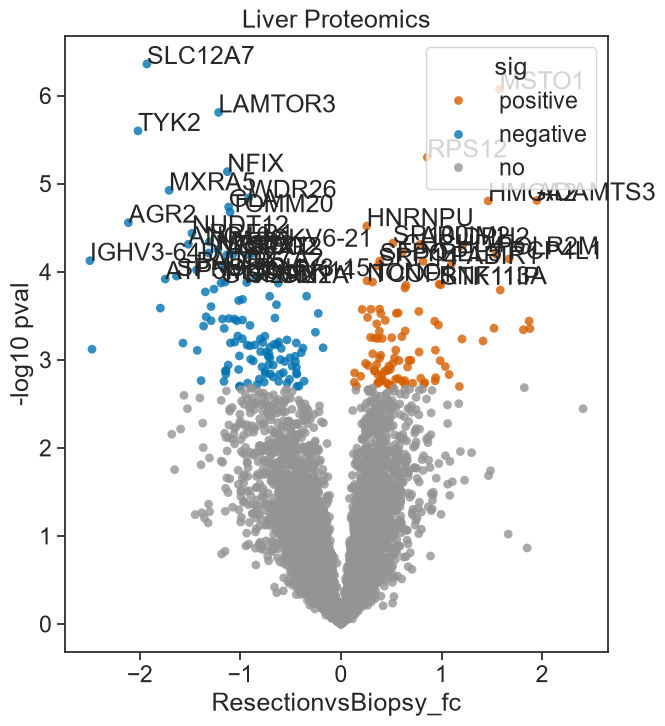

In [595]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)
                

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('Liver Proteomics')
#plt.show()
plt.savefig(f'Volcano_proteomics_liver_output_{today}.pdf', bbox_inches='tight', dpi=300)

In [596]:
df_ttest_.to_csv(f'prot_ttest_liver_{today}.csv')

## 17. Non-tumor pathway enrichment

Define significant and background genes, query Hallmark enrichment, and annotate exported pathway members.

In [598]:
msig = Msigdb()
gmt = msig.get_gmt(category='h.all', dbver="2025.1.Hs")

#gmt = msig.get_gmt(category='c2.all', dbver="2025.1.Hs")

In [601]:
df_ttest_liver = df_ttest_.copy()
df_liver_sig = most_sig[most_sig.sig != 'no'].copy()
df_liver_sig.shape

(222, 39)

In [603]:
new_sig_genes = set()
for gene in df_liver_sig.Gene.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            new_sig_genes.add(g)
    else:
        new_sig_genes.add(gene)

In [604]:
bg_genes = set()
for gene in df_liver_imputed.index.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            bg_genes.add(g)
    else:
        bg_genes.add(gene)

In [605]:
enr_res = gp.enrichr(gene_list=list(new_sig_genes),
 gene_sets=gmt,
 organism='h. sapiens',
 outdir='HM/',
 background=list(bg_genes),
cutoff=1
 )

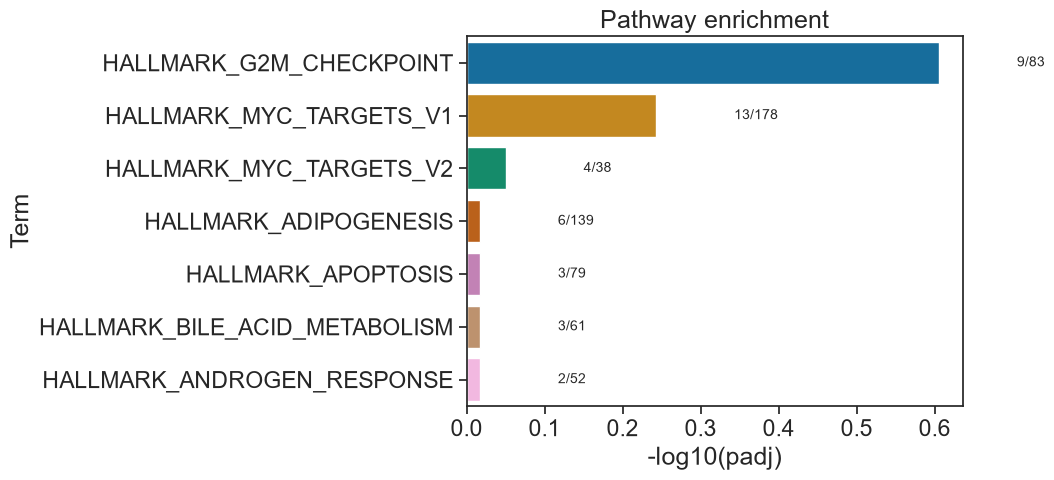

In [606]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
#path_res_sig = path_res[path_res['P-value'] < 0.05].reset_index()

# Barplot
g = sns.barplot(data=path_res.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    g.text(width + 0.1, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
plt.savefig(f'figures/HM_liver_proteomics_pathway_enrichment_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [607]:
# Extract genes in each pathway
pathway_genes = {}
path_res_sig = path_res[path_res['P-value'] < 0.05].reset_index()
for row in path_res_sig.iterrows():
    genes = set(row[1]['Genes'].split(';'))
    path = row[1]['Term']
    pathway_genes[path] = genes

In [608]:
pathway_genes

{'HALLMARK_G2M_CHECKPOINT': {'EWSR1',
  'G3BP1',
  'HNRNPD',
  'HNRNPU',
  'MAPK14',
  'RBM14',
  'SFPQ',
  'SQLE',
  'XPO1'},
 'HALLMARK_MYC_TARGETS_V1': {'ETF1',
  'G3BP1',
  'HNRNPA3',
  'HNRNPD',
  'HNRNPU',
  'NHP2',
  'NPM1',
  'PPIA',
  'PRDX3',
  'PTGES3',
  'RANBP1',
  'SNRPD2',
  'XPO1'}}

In [609]:
path_res.to_csv(f'proteome_non-tumor_hallmark_{today}.csv')

In [610]:
# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_liver['Hallmark'] = df_ttest_liver.Gene.map(hm_dict)
df_ttest_liver.head()

,Gene,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Hallmark
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
SLC12A7,SLC12A7,17.100197,16.646917,16.759249,17.266504,17.569672,16.561422,16.874226,16.589472,0.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,14.812153,14.632030,14.388291,15.257084,14.926704,16.104353,15.041982,14.761349,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,-17.792835,4.370220e-07,-1.930463,0.002309,6.359497,negative,NaN
MSTO1,MSTO1,16.504225,16.516554,16.573767,16.559359,16.451363,16.411146,16.513044,16.465147,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,18.012671,18.154995,18.162909,17.726984,17.611818,18.287792,18.282206,18.376791,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,16.155794,8.466601e-07,1.577696,0.002309,6.072291,positive,NaN
LAMTOR3,LAMTOR3,19.521130,19.408451,19.034451,19.343281,19.208059,18.883289,19.724636,19.155533,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.891737,18.193802,17.653042,18.393078,17.583847,18.294718,18.480665,18.047611,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-14.782091,1.552406e-06,-1.217541,0.002822,5.808995,negative,NaN
TYK2,TYK2,23.294153,22.271549,23.329676,23.455700,23.156265,22.738579,23.320511,23.166784,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,20.879461,21.074434,21.317438,21.553034,20.973421,20.812956,20.869110,21.101465,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,-13.767235,2.516687e-06,-2.018988,0.003432,5.599171,negative,[HALLMARK_IL6_JAK_STAT3_SIGNALING]
RPS12,RPS12,23.624598,23.842323,23.916519,24.018530,24.032473,23.956059,23.916277,23.975374,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.390457,24.859428,24.989433,24.612215,24.870752,25.072479,24.491358,24.865585,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.429561,5.019789e-06,0.858696,0.005476,5.299314,positive,[HALLMARK_P53_PATHWAY]


## 18. HCC differential abundance and enrichment

Repeat the paired test, plotting, and Hallmark enrichment workflow in HCC.

In [612]:
res = students_ttest(
    df=df_hcc_imputed,
    group_cols=metadata_hcc[metadata_hcc.Sample_type == 'Resection'].index,
    control_cols=metadata_hcc[metadata_hcc.Sample_type == 'Biopsy'].index,
    group_name="Resection",
    control_name="Biopsy",
    paired=True,
    pairing=metadata_hcc.patient_id,
)

In [613]:
res.head()

,ID,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511761,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776831,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386669,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908039,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401
REXO4,REXO4,19.126024,18.871603,19.694807,19.151979,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955971,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566


In [614]:
df_hcc_imputed.head()

,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.255272,22.353943,23.569225,23.161396,24.026705,22.659174,23.613865,22.270475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.967411,22.219536,22.301674,22.981184,21.408100,22.423550,22.785063,21.406275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,22.648235,21.949207,22.197075,22.566017,22.523945,23.312183,23.249437,21.974596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.577009,22.293673,22.284140,22.376797,23.050961,22.686665,22.996695,22.447262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,24.140676,24.282225,26.508230,25.480110,25.168591,23.044794,24.995989,23.947323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.881674,23.141455,23.304840,24.875446,21.337704,22.701815,23.112858,22.996946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.742456,17.001955,17.750624,18.114475,17.346569,18.056957,17.171499,17.787691,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.265703,17.282082,18.008360,17.719534,17.202330,16.964922,16.974493,17.633694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AACS,16.387304,16.295835,16.375607,16.317015,16.930548,16.818823,17.347580,16.177885,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,16.143217,15.985530,15.229109,16.047270,15.980369,16.047676,16.039684,15.806023,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0


In [615]:
res['-log10 pval'] = -np.log10(res['ResectionvsBiopsy_pval'])

In [616]:
res = res.rename({'ID':'Gene'}, axis=1)
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511761,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374,6.397505
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776831,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386669,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460,6.081074
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908039,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401,5.055348
REXO4,REXO4,19.126024,18.871603,19.694807,19.151979,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955971,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566,4.809382
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566,4.782584


In [617]:
res.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511761,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374,6.397505
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776831,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386669,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460,6.081074
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908039,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401,5.055348
REXO4,REXO4,19.126024,18.871603,19.694807,19.151979,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955971,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566,4.809382
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566,4.782584


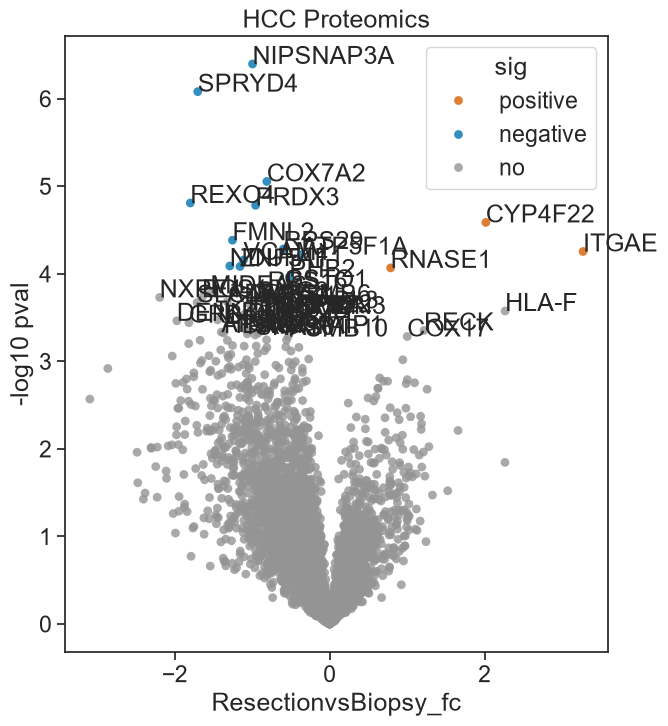

In [618]:
df_ttest_ = res.copy()

df_ttest_['sig'] = np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                            (df_ttest_['ResectionvsBiopsy_fc'] > 0), 'positive',
                    np.where((df_ttest_['ResectionvsBiopsy_adj_pval'] < 0.05) &\
                             (df_ttest_['ResectionvsBiopsy_fc'] < 0), 'negative', 
                                    'no'))

fig, ax = plt.subplots(figsize=(7,8))

colors = sns.color_palette('colorblind')

sns.scatterplot(data=df_ttest_, x='ResectionvsBiopsy_fc', y='-log10 pval',
                hue='sig', alpha=0.8, linewidth=0, palette=[colors[3], colors[0], colors[7]],
                hue_order=['positive', 'negative', 'no'], s=40)

most_sig = df_ttest_.sort_values('-log10 pval', ascending=False)

for i in range(0,50):
    x = most_sig.iloc[i,:]['ResectionvsBiopsy_fc'].item()
    y = most_sig.iloc[i,:]['-log10 pval'].item()
    label = most_sig.iloc[i,:]['Gene'] 
    plt.text(x=x, y=y, s=label)
    
plt.title('HCC Proteomics')
#plt.show()
plt.savefig(f'Volcano_proteomics_hcc_output_{today}.pdf', bbox_inches='tight', dpi=300)

In [619]:
df_ttest_.to_csv(f'prot_ttest_hcc_{today}.csv')

In [620]:
df_ttest_hcc = df_ttest_.copy()
df_hcc_sig = most_sig[most_sig.sig != 'no'].copy()
df_hcc_sig.shape

(15, 39)

In [621]:
new_sig_genes = set()
for gene in df_hcc_sig.Gene.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            new_sig_genes.add(g)
    else:
        new_sig_genes.add(gene)

In [622]:
new_sig_genes

{'ATP5F1A',
 'COX7A2',
 'CYP4F22',
 'FMNL2',
 'ITGAE',
 'NDUFAF1',
 'NIPSNAP3A',
 'PHB2',
 'PRDX3',
 'REXO4',
 'RNASE1',
 'RPS29',
 'SPRYD4',
 'VCAM1',
 'ZNF511'}

In [623]:
bg_genes = set()
for gene in df_hcc_imputed.index.tolist():
    if ';' in gene:
        genes = gene.split(';')
        
        for g in genes:
            bg_genes.add(g)
    else:
        bg_genes.add(gene)

In [624]:
enr_res = gp.enrichr(gene_list=list(new_sig_genes),
 gene_sets=gmt,
 organism='h. sapiens',
 outdir='HM_hcc/',
 background=list(bg_genes),
cutoff=.9
 )

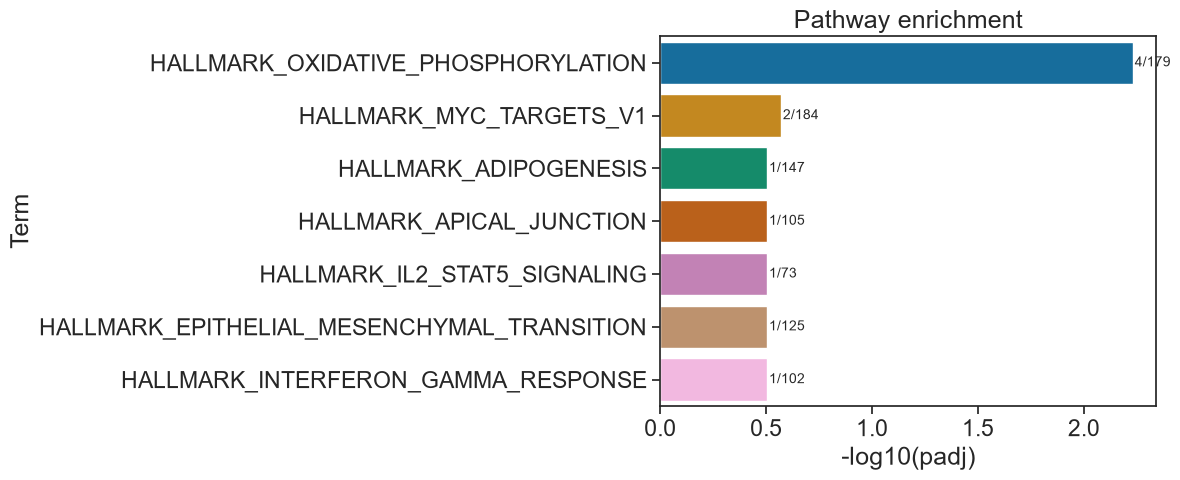

In [625]:
path_res = enr_res.results
path_res = path_res.sort_values('Adjusted P-value').reset_index(drop=True)

path_res['count'] = path_res.Overlap.str.split('/').str[0].astype(int) / path_res.Overlap.str.split('/').str[1].astype(int)
path_res['-log10(padj)'] = -np.log10(path_res['Adjusted P-value'])
#path_res_sig = path_res[path_res['P-value'] < 0.05].reset_index()

# Barplot
g = sns.barplot(data=path_res.iloc[:7,:], y='Term', x='-log10(padj)', 
                   palette=sns.color_palette('colorblind'), orient='h')

# Annotate bars with Overlap values
for i, (bar, overlap) in enumerate(zip(g.patches, path_res.iloc[:7]['Overlap'])):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    g.text(width + 0.01, y, overlap, va='center', ha='left', fontsize=10)

plt.title('Pathway enrichment')
plt.savefig(f'figures/HM_hcc_proteomics_pathway_enrichment_{today}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [626]:
path_res.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes,count,-log10(padj)
0,gs_ind_0,HALLMARK_OXIDATIVE_PHOSPHORYLATION,4/179,0.000841,0.005890,12.810479,90.702735,PRDX3;COX7A2;ATP5F1A;PHB2,0.022346,2.229861
1,gs_ind_0,HALLMARK_MYC_TARGETS_V1,2/184,0.077058,0.269705,5.822933,14.925289,PRDX3;PHB2,0.010870,0.569112
2,gs_ind_0,HALLMARK_ADIPOGENESIS,1/147,0.313846,0.313846,4.077557,4.725287,PRDX3,0.006803,0.503283
3,gs_ind_0,HALLMARK_APICAL_JUNCTION,1/105,0.235145,0.313846,5.757961,8.334942,VCAM1,0.009524,0.503283
4,gs_ind_0,HALLMARK_IL2_STAT5_SIGNALING,1/73,0.169613,0.313846,8.345065,14.806113,ITGAE,0.013699,0.503283


In [627]:
# Populate export table with pathway gene identity

hm_dict = {}

for row in path_res.iterrows():
    term = row[1][1]
    genes = row[1]['Genes'].split(';')
    for gene in genes:
        if gene in hm_dict.keys():
            prev_term = hm_dict[gene]
            prev_term.append(term)
            hm_dict[gene] = prev_term
        else:
            hm_dict[gene] = [term]
            
df_ttest_hcc['Hallmark'] = df_ttest_hcc.Gene.map(hm_dict)
df_ttest_hcc.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig,Hallmark
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511761,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374,6.397505,negative,NaN
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776831,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386669,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460,6.081074,negative,NaN
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908039,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401,5.055348,negative,[HALLMARK_OXIDATIVE_PHOSPHORYLATION]
REXO4,REXO4,19.126024,18.871603,19.694807,19.151979,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955971,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566,4.809382,negative,NaN
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566,4.782584,negative,"[HALLMARK_OXIDATIVE_PHOSPHORYLATION, HALLMARK_..."


## 19. Consolidated proteomics export

Combine imputed intensities, paired t-test statistics, and limma sensitivity results.

In [628]:
df_liver_imputed.shape

(5454, 32)

In [629]:
df_hcc_imputed.shape

(5930, 32)

In [630]:
merged_imputed = pd.concat([df_liver_imputed, df_hcc_imputed], axis=1)
merged_imputed.isna().sum()

non-tumor_Biopsy_D                    628
non-tumor_Biopsy_N                    628
non-tumor_Biopsy_O                    628
non-tumor_Biopsy_Q                    628
non-tumor_Biopsy_I                    628
                                     ... 
missingindicator_tumor_Resection_Q    152
missingindicator_tumor_Resection_T    152
missingindicator_tumor_Resection_I    152
missingindicator_tumor_Resection_L    152
missingindicator_tumor_Resection_E    152
Length: 64, dtype: int64

In [631]:
merged_imputed.head()

,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Biopsy_L,non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_E,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_E,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_E,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E
Genes,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A1BG,23.583744,22.691730,23.700348,23.783178,23.227478,23.720911,23.706333,23.631907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.182013,23.628981,23.128525,23.448261,23.453941,22.796499,22.783865,22.583464,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.255272,22.353943,23.569225,23.161396,24.026705,22.659174,23.613865,22.270475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.967411,22.219536,22.301674,22.981184,21.408100,22.423550,22.785063,21.406275,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A1CF,23.080559,23.435858,22.928110,22.980057,22.957027,23.153534,22.424751,23.104027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.178709,23.274574,23.463631,23.130199,23.366055,23.201015,22.328712,23.273979,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.648235,21.949207,22.197075,22.566017,22.523945,23.312183,23.249437,21.974596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.577009,22.293673,22.284140,22.376797,23.050961,22.686665,22.996695,22.447262,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A2M,25.333908,24.084978,26.270123,26.097136,24.362339,23.918167,25.778812,25.927792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.939219,25.212572,24.586401,25.354807,23.439011,23.307871,23.845980,23.917244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.140676,24.282225,26.508230,25.480110,25.168591,23.044794,24.995989,23.947323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.881674,23.141455,23.304840,24.875446,21.337704,22.701815,23.112858,22.996946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAS,17.384706,16.505604,17.065168,17.483335,17.184856,17.359283,17.239319,17.169897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.732097,17.161808,15.998487,17.370012,17.545244,16.714172,17.126320,16.796206,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.742456,17.001955,17.750624,18.114475,17.346569,18.056957,17.171499,17.787691,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,17.265703,17.282082,18.008360,17.719534,17.202330,16.964922,16.974493,17.633694,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AADAC,22.620520,21.969687,21.337917,21.287830,21.983412,21.202602,21.013498,21.389828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.642092,21.451967,20.851093,21.695572,21.056515,21.790756,20.498693,20.994833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.046265,21.003126,20.011145,20.393961,20.786316,22.036106,20.515812,19.411783,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21.530720,21.103718,21.224411,19.637308,20.56114

In [632]:
merge_limma = liver_limma['results'].merge(hcc_limma['results'], right_index=True, left_index=True, suffixes=('_limma_non-tumor', '_limma_tumor'))

In [633]:
merged = df_ttest_liver.loc[:,'ResectionvsBiopsy_tstat':].merge(df_ttest_hcc.loc[:,'ResectionvsBiopsy_tstat':], right_index=True, left_index=True, suffixes=('_knn_non-tumor', '_knn_tumor'))
merged.head()

,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,-log10 pval_knn_non-tumor,sig_knn_non-tumor,Hallmark_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_adj_pval_knn_tumor,-log10 pval_knn_tumor,sig_knn_tumor,Hallmark_knn_tumor
ID,,,,,,,,,,,,,,
SLC12A7,-17.792835,4.370220e-07,-1.930463,0.002309,6.359497,negative,NaN,-0.866961,0.414690,-0.256052,0.668955,0.382276,no,NaN
MSTO1,16.155794,8.466601e-07,1.577696,0.002309,6.072291,positive,NaN,1.920977,0.096191,0.512409,0.343360,1.016864,no,NaN
LAMTOR3,-14.782091,1.552406e-06,-1.217541,0.002822,5.808995,negative,NaN,-4.748672,0.002087,-1.021412,0.089741,2.680533,no,NaN
RPS12,12.429561,5.019789e-06,0.858696,0.005476,5.299314,positive,[HALLMARK_P53_PATHWAY],3.634622,0.008346,0.307692,0.135601,2.078497,no,NaN
NFIX,-11.753410,7.308151e-06,-1.130318,0.006643,5.136192,negative,NaN,0.984337,0.357742,0.294056,0.624290,0.446430,no,NaN


In [667]:
proteome_export = pd.concat([merged, merge_limma, merged_imputed], axis=1)

In [668]:
proteome_export = proteome_export.loc[:,sorted(proteome_export.columns.tolist())]

In [669]:
proteome_export.to_csv(f"proteome_export_{today}.csv")

In [637]:
proteome_export.head()

,-log10 pval_knn_non-tumor,-log10 pval_knn_tumor,AveExpr_limma_non-tumor,AveExpr_limma_tumor,B_limma_non-tumor,B_limma_tumor,Hallmark_knn_non-tumor,Hallmark_knn_tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,adj_pvalue_limma_non-tumor,adj_pvalue_limma_tumor,effect_limma_non-tumor,effect_limma_tumor,incomplete_pair_fraction_limma_non-tumor,incomplete_pair_fraction_limma_tumor,lfcSE_limma_non-tumor,lfcSE_limma_tumor,log2FoldChange_limma_non-tumor,log2FoldChange_limma_tumor,mean_log2_intensity_limma_non-tumor,mean_log2_intensity_limma_tumor,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_E,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_E,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_E,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,n_complete_pairs_limma_non-tumor,n_complete_pairs_limma_tumor,n_incomplete_pairs_limma_non-tumor,n_incomplete_pairs_limma_tumor,n_raw_missing_values_limma_non-tumor,n_raw_missing_values_limma_tumor,n_raw_observed_values_limma_non-tumor,n_raw_observed_values_limma_tumor,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,pvalue_limma_non-tumor,pvalue_limma_tumor,raw_missing_fraction_limma_non-tumor,raw_missing_fraction_limma_tumor,sig_knn_non-tumor,sig_knn_tumor,significant_FDR_0.05_limma_non-tumor,significant_FDR_0.05_limma_tumor,stat_limma_non-tumor,stat_limma_tumor,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
SLC12A7,6.359497,0.382276,NaN,NaN,NaN,NaN,NaN,NaN,0.002309,0.668955,-1.930463,-0.256052,4.370220e-07,0.414690,-17.792835,-0.866961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.100197,16.589472,17.569672,16.874226,16.646917,16.759249,17.266504,16.561422,14.812153,14.761349,16.104353,15.041982,14.632030,14.388291,15.257084,14.926704,NaN,NaN,NaN,NaN,negative,no,NaN,NaN,NaN,NaN,17.976278,16.860119,17.892241,17.073469,16.676289,17.883566,17.578438,17.000380,17.043846,16.668724,16.185110,17.602072,16.768925,17.257826,17.424383,17.941473
MSTO1,6.072291,1.016864,NaN,NaN,NaN,NaN,NaN,NaN,0.002309,0.343360,1.577696,0.512409,8.466601e-07,0.096191,16.155794,1.920977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0

In [638]:
non_tum_mask = proteome_export.loc[:,'missingindicator_non-tumor_Biopsy_D':'missingindicator_non-tumor_Biopsy_T'].sum(axis=1) == 7

In [639]:
proteome_export.loc[:,'missingindicator_non-tumor_Biopsy_D':'missingindicator_non-tumor_Biopsy_T'].columns

Index(['missingindicator_non-tumor_Biopsy_D',
       'missingindicator_non-tumor_Biopsy_E',
       'missingindicator_non-tumor_Biopsy_I',
       'missingindicator_non-tumor_Biopsy_L',
       'missingindicator_non-tumor_Biopsy_N',
       'missingindicator_non-tumor_Biopsy_O',
       'missingindicator_non-tumor_Biopsy_Q',
       'missingindicator_non-tumor_Biopsy_T'],
      dtype='object')

In [640]:
non_tum_mask.sum()

np.int64(107)

In [641]:
proteome_export[non_tum_mask]

,-log10 pval_knn_non-tumor,-log10 pval_knn_tumor,AveExpr_limma_non-tumor,AveExpr_limma_tumor,B_limma_non-tumor,B_limma_tumor,Hallmark_knn_non-tumor,Hallmark_knn_tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,adj_pvalue_limma_non-tumor,adj_pvalue_limma_tumor,effect_limma_non-tumor,effect_limma_tumor,incomplete_pair_fraction_limma_non-tumor,incomplete_pair_fraction_limma_tumor,lfcSE_limma_non-tumor,lfcSE_limma_tumor,log2FoldChange_limma_non-tumor,log2FoldChange_limma_tumor,mean_log2_intensity_limma_non-tumor,mean_log2_intensity_limma_tumor,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_E,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_E,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_E,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,n_complete_pairs_limma_non-tumor,n_complete_pairs_limma_tumor,n_incomplete_pairs_limma_non-tumor,n_incomplete_pairs_limma_tumor,n_raw_missing_values_limma_non-tumor,n_raw_missing_values_limma_tumor,n_raw_observed_values_limma_non-tumor,n_raw_observed_values_limma_tumor,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,pvalue_limma_non-tumor,pvalue_limma_tumor,raw_missing_fraction_limma_non-tumor,raw_missing_fraction_limma_tumor,sig_knn_non-tumor,sig_knn_tumor,significant_FDR_0.05_limma_non-tumor,significant_FDR_0.05_limma_tumor,stat_limma_non-tumor,stat_limma_tumor,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
MSTO1,6.072291,1.016864,NaN,NaN,NaN,NaN,NaN,NaN,0.002309,0.343360,1.577696,0.512409,8.466601e-07,0.096191,16.155794,1.920977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.504225,16.465147,16.451363,16.513044,16.516554,16.573767,16.559359,16.411146,18.012671,18.376791,18.287792,18.282206,18.154995,18.162909,17.726984,17.611818,NaN,NaN,NaN,NaN,positive,no,NaN,NaN,NaN,NaN,18.389679,17.868895,18.642237,17.772978,16.809389,19.685747,17.799276,18.560020,17.925663,18.740419,18.211058,17.972437,18.505453,19.946609,18.727201,19.598667
NFIX,5.136192,0.446430,NaN,NaN,NaN,NaN,NaN,NaN,0.006643,0.624290,-1.130318,0.294056,7.308151e-06,0.357742,-11.753410,0.984337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.

In [642]:
tum_mask = proteome_export.loc[:,'missingindicator_tumor_Biopsy_D':'missingindicator_tumor_Biopsy_T'].sum(axis=1) == 7

In [536]:
tum_mask.sum()

np.int64(132)

In [537]:
proteome_export[tum_mask]

,-log10 pval_knn_non-tumor,-log10 pval_knn_tumor,AveExpr_limma_non-tumor,AveExpr_limma_tumor,B_limma_non-tumor,B_limma_tumor,Hallmark_knn_non-tumor,Hallmark_knn_tumor,ResectionvsBiopsy_adj_pval_knn_non-tumor,ResectionvsBiopsy_adj_pval_knn_tumor,ResectionvsBiopsy_fc_knn_non-tumor,ResectionvsBiopsy_fc_knn_tumor,ResectionvsBiopsy_pval_knn_non-tumor,ResectionvsBiopsy_pval_knn_tumor,ResectionvsBiopsy_tstat_knn_non-tumor,ResectionvsBiopsy_tstat_knn_tumor,adj_pvalue_limma_non-tumor,adj_pvalue_limma_tumor,effect_limma_non-tumor,effect_limma_tumor,incomplete_pair_fraction_limma_non-tumor,incomplete_pair_fraction_limma_tumor,lfcSE_limma_non-tumor,lfcSE_limma_tumor,log2FoldChange_limma_non-tumor,log2FoldChange_limma_tumor,mean_log2_intensity_limma_non-tumor,mean_log2_intensity_limma_tumor,missingindicator_non-tumor_Biopsy_D,missingindicator_non-tumor_Biopsy_E,missingindicator_non-tumor_Biopsy_I,missingindicator_non-tumor_Biopsy_L,missingindicator_non-tumor_Biopsy_N,missingindicator_non-tumor_Biopsy_O,missingindicator_non-tumor_Biopsy_Q,missingindicator_non-tumor_Biopsy_T,missingindicator_non-tumor_Resection_D,missingindicator_non-tumor_Resection_E,missingindicator_non-tumor_Resection_I,missingindicator_non-tumor_Resection_L,missingindicator_non-tumor_Resection_N,missingindicator_non-tumor_Resection_O,missingindicator_non-tumor_Resection_Q,missingindicator_non-tumor_Resection_T,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_E,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_E,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,n_complete_pairs_limma_non-tumor,n_complete_pairs_limma_tumor,n_incomplete_pairs_limma_non-tumor,n_incomplete_pairs_limma_tumor,n_raw_missing_values_limma_non-tumor,n_raw_missing_values_limma_tumor,n_raw_observed_values_limma_non-tumor,n_raw_observed_values_limma_tumor,non-tumor_Biopsy_D,non-tumor_Biopsy_E,non-tumor_Biopsy_I,non-tumor_Biopsy_L,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_E,non-tumor_Resection_I,non-tumor_Resection_L,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,pvalue_limma_non-tumor,pvalue_limma_tumor,raw_missing_fraction_limma_non-tumor,raw_missing_fraction_limma_tumor,sig_knn_non-tumor,sig_knn_tumor,significant_FDR_0.05_limma_non-tumor,significant_FDR_0.05_limma_tumor,stat_limma_non-tumor,stat_limma_tumor,tumor_Biopsy_D,tumor_Biopsy_E,tumor_Biopsy_I,tumor_Biopsy_L,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_T,tumor_Resection_D,tumor_Resection_E,tumor_Resection_I,tumor_Resection_L,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T
GLE1,1.832961,0.546272,NaN,NaN,NaN,NaN,NaN,NaN,0.152905,0.579481,-0.273632,-0.328793,0.014691,0.284268,-3.218173,-1.159506,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.715612,17.675005,17.770580,17.783136,17.685091,17.659706,17.414640,17.337046,17.437042,17.647942,17.308146,17.276737,17.073313,17.438141,17.254519,17.415932,NaN,NaN,NaN,NaN,no,no,NaN,NaN,NaN,NaN,18.385487,17.992392,18.835342,19.047480,17.921610,17.679741,18.509962,16.657785,18.298246,17.171217,17.670280,17.859539,18.649286,17.353178,17.832922,17.564783
SLC47A1,1.436873,1.506962,NaN,NaN,NaN,NaN,NaN,NaN,0.219421,0.290959,0.226868,-0.738537,0.036570,0.031120,2.578162,-2.689242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,

## 20. Cross-tissue significant-protein overlap

Assemble the significant sets and generate the Venn diagram reported in Figure 3G. Cross-tissue fold-change correlations were removed following reviewer feedback.

In [643]:
df_heatmap_l = df_liver_sig.iloc[:,-6:].copy()
df_heatmap_h = df_hcc_sig.iloc[:,-6:].copy()

df_heatmap_l = df_heatmap_l.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap_h = df_heatmap_h.drop(['ResectionvsBiopsy_tstat', 'ResectionvsBiopsy_pval',
                                  'ResectionvsBiopsy_adj_pval'], axis=1)

df_heatmap = df_heatmap_l.merge(df_heatmap_h, left_index=True, right_index=True, suffixes=('_liver', '_hcc'), how='outer')
#df_heatmap.index = df_heatmap.Gene_liver
df_heatmap.head()

,ResectionvsBiopsy_fc_liver,-log10 pval_liver,sig_liver,ResectionvsBiopsy_fc_hcc,-log10 pval_hcc,sig_hcc
ID,,,,,,
ABCD1,-1.263554,3.802272,negative,NaN,NaN,NaN
ABLIM2,0.788555,4.312450,positive,NaN,NaN,NaN
ACIN1,0.270607,2.935102,positive,NaN,NaN,NaN
ADAMTS3,1.948296,4.809718,positive,NaN,NaN,NaN
AGFG2,0.294050,3.254164,positive,NaN,NaN,NaN


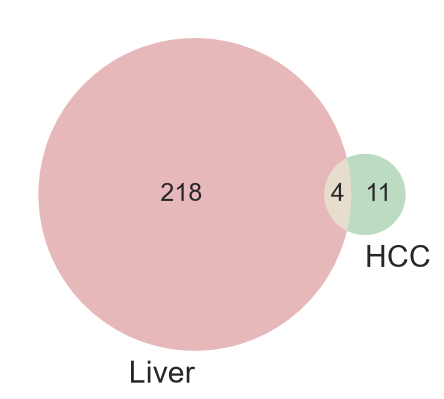

In [645]:
set1 = set(df_heatmap.ResectionvsBiopsy_fc_liver.dropna().index)
set2 = set(df_heatmap.ResectionvsBiopsy_fc_hcc.dropna().index)

venn2([set1, set2], ('Liver', 'HCC'))

plt.savefig(f'figures/venn_proteome_{today}.pdf', dpi=300, bbox_inches='tight')

## 21. Imputation and limma revision audit

Quantify imputation among original hits and compare the imputation-based paired analysis with the non-imputed limma sensitivity analysis reported in the Results and Supplementary Table 3.

In [648]:
def summarize_imputation_for_hits(
    raw_expression,
    sample_names,
    significant_features,
):
    """
    Summarize missing entries that required KNN imputation in the
    original analysis.

    raw_expression must be the matrix before KNN imputation.
    """

    sample_names = [
        str(sample) for sample in sample_names
        if str(sample) in raw_expression.columns.astype(str)
    ]

    raw = raw_expression.copy()
    raw.columns = raw.columns.astype(str)
    raw = raw.loc[:, sample_names]

    missing_mask = raw.isna()

    significant_features = pd.Index(
        significant_features
    ).drop_duplicates()

    significant_features = significant_features.intersection(
        raw.index
    )

    per_hit = pd.DataFrame(
        {
            "n_observed": raw.loc[
                significant_features
            ].notna().sum(axis=1),

            "n_imputed_in_original_analysis": raw.loc[
                significant_features
            ].isna().sum(axis=1),

            "imputed_fraction": raw.loc[
                significant_features
            ].isna().mean(axis=1),
        }
    )

    per_hit["contained_no_imputed_values"] = (
        per_hit["n_imputed_in_original_analysis"] == 0
    )

    hits_with_imputation = (
        per_hit["n_imputed_in_original_analysis"] > 0
    )

    median_imputed = (
        per_hit.loc[
            hits_with_imputation,
            "n_imputed_in_original_analysis",
        ].median()
        if hits_with_imputation.any()
        else 0
    )

    n_hits = per_hit.shape[0]
    n_zero_imputed = int(
        per_hit["contained_no_imputed_values"].sum()
    )

    summary = pd.Series(
        {
            "matrix_entries": raw.size,
            "matrix_missing_or_imputed_entries": int(
                missing_mask.sum().sum()
            ),
            "matrix_percent_imputed": (
                100 * missing_mask.sum().sum() / raw.size
            ),
            "significant_hits_found_in_matrix": n_hits,
            "significant_hits_with_zero_imputation": n_zero_imputed,
            "percent_significant_hits_with_zero_imputation": (
                100 * n_zero_imputed / n_hits
                if n_hits > 0
                else np.nan
            ),
            "significant_hits_with_imputation": int(
                hits_with_imputation.sum()
            ),
            "median_imputed_values_among_hits_with_imputation": (
                median_imputed
            ),
        },
        name="imputation_summary",
    )

    return summary, per_hit.sort_values(
        "n_imputed_in_original_analysis",
        ascending=False,
    )

In [649]:
df_hcc_sig.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511761,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374,6.397505,negative
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776831,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386669,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460,6.081074,negative
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908039,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401,5.055348,negative
REXO4,REXO4,19.126024,18.871603,19.694807,19.151979,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955971,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566,4.809382,negative
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566,4.782584,negative


In [650]:
df_liver.head()

Run,non-tumor_Biopsy_D,non-tumor_Biopsy_N,non-tumor_Biopsy_O,non-tumor_Biopsy_Q,non-tumor_Biopsy_I,non-tumor_Biopsy_T,non-tumor_Resection_D,non-tumor_Resection_N,non-tumor_Resection_O,non-tumor_Resection_Q,non-tumor_Resection_T,non-tumor_Resection_I,non-tumor_Biopsy_L,non-tumor_Biopsy_E,non-tumor_Resection_L,non-tumor_Resection_E
Genes,,,,,,,,,,,,,,,,
A1BG,23.583744,22.691730,23.700348,23.783178,23.227478,23.720911,23.182013,23.628981,23.128525,23.448261,23.453941,22.796499,23.706333,23.631907,22.783865,22.583464
A1CF,23.080559,23.435858,22.928110,22.980057,22.957027,23.153534,23.178709,23.274574,23.463631,23.130199,23.366055,23.201015,22.424751,23.104027,22.328712,23.273979
A2M,25.333908,24.084978,26.270123,26.097136,24.362339,23.918167,23.939219,25.212572,24.586401,25.354807,23.439011,23.307871,25.778812,25.927792,23.845980,23.917244
AAAS,17.384706,16.505604,17.065168,17.483335,17.184856,17.359283,15.732097,17.161808,NaN,17.370012,17.545244,16.714172,17.239319,17.169897,17.126320,16.796206
AADAC,22.620520,21.969687,21.337917,21.287830,21.983412,21.202602,20.642092,21.451967,20.851093,21.695572,21.056515,21.790756,21.013498,21.389828,20.498693,20.994833


In [651]:
liver_limma["matrix"].columns

Index(['D', 'E', 'I', 'L', 'N', 'O', 'Q', 'T'], dtype='object')

In [652]:

old_liver_significant = df_liver_sig.index

old_hcc_significant = df_hcc_sig.index

In [653]:
# liver_imputation_summary, liver_hit_missingness = (
#     summarize_imputation_for_hits(
#         raw_expression=df_liver,
#         sample_names=df_liver.columns,
#         significant_features=old_liver_significant,
#     )
# )
liver_imputation_summary, liver_hit_missingness = (
    summarize_imputation_for_hits(
        raw_expression=df_liver,
        sample_names=liver_limma["paired_samples"],
        significant_features=old_liver_significant,
    )
)

# hcc_imputation_summary, hcc_hit_missingness = (
#     summarize_imputation_for_hits(
#         raw_expression=df_hcc,
#         sample_names=df_hcc.columns,
#         significant_features=old_hcc_significant,
#     )
# )

hcc_imputation_summary, hcc_hit_missingness = (
    summarize_imputation_for_hits(
        raw_expression=df_hcc,
        sample_names=hcc_limma["paired_samples"],
        significant_features=old_hcc_significant,
    )
)

display(liver_imputation_summary.to_frame())
display(hcc_imputation_summary.to_frame())

,imputation_summary
matrix_entries,87264.000000
matrix_missing_or_imputed_entries,12480.000000
matrix_percent_imputed,14.301430
significant_hits_found_in_matrix,222.000000
significant_hits_with_zero_imputation,103.000000
percent_significant_hits_with_zero_imputation,46.396396
significant_hits_with_imputation,119.000000
median_imputed_values_among_hits_with_imputation,10.000000


,imputation_summary
matrix_entries,94880.000000
matrix_missing_or_imputed_entries,15905.000000
matrix_percent_imputed,16.763280
significant_hits_found_in_matrix,15.000000
significant_hits_with_zero_imputation,7.000000
percent_significant_hits_with_zero_imputation,46.666667
significant_hits_with_imputation,8.000000
median_imputed_values_among_hits_with_imputation,10.500000


In [654]:
liver_limma['results'].head()

,n_complete_pairs,n_incomplete_pairs,incomplete_pair_fraction,n_raw_observed_values,n_raw_missing_values,raw_missing_fraction,mean_log2_intensity,log2FoldChange,lfcSE,AveExpr,stat,pvalue,adj_pvalue,B,effect,significant_FDR_0.05
Genes,,,,,,,,,,,,,,,,
RPS12,8,0,0.000,16,0,0.0000,24.339617,0.858695,0.353553,0.858695,9.523548,6.991414e-07,0.002130,6.158040,Resection - Biopsy,True
LAMTOR3,7,1,0.125,15,1,0.0625,18.701508,-1.260998,0.377964,-1.260998,-9.884948,9.726241e-07,0.002130,6.382893,Resection - Biopsy,True
COX7A2,8,0,0.000,16,0,0.0000,21.705036,-1.155789,0.353553,-1.155789,-8.558075,2.125213e-06,0.003102,5.197068,Resection - Biopsy,True
IGKV3-11,8,0,0.000,16,0,0.0000,23.100170,-1.017438,0.353553,-1.017438,-7.585545,7.187411e-06,0.007437,4.108950,Resection - Biopsy,True
COX7C,8,0,0.000,16,0,0.0000,20.456713,-1.341125,0.353553,-1.341125,-7.458816,8.491630e-06,0.007437,3.957525,Resection - Biopsy,True


In [655]:
liver_hit_audit = liver_hit_missingness.join(
    liver_limma['results'][
        [
            "log2FoldChange",
            "pvalue",
            "adj_pvalue",
            "n_complete_pairs",
        ]
    ],
    how="left",
)

hcc_hit_audit = hcc_hit_missingness.join(
    hcc_limma['results'][
        [
            "log2FoldChange",
            "pvalue",
            "adj_pvalue",
            "n_complete_pairs",
        ]
    ],
    how="left",
)

liver_hit_audit.to_csv(
    "liver_original_hits_imputation_and_limma_audit.csv"
)

hcc_hit_audit.to_csv(
    "hcc_original_hits_imputation_and_limma_audit.csv"
)

In [656]:
def compare_original_with_limma(
    original_results,
    limma_results,
    *,
    original_q_column,
    original_lfc_column,
    alpha=0.05,
):
    original = original_results[
        [original_q_column, original_lfc_column]
    ].copy()

    original = original.rename(
        columns={
            original_q_column: "original_qvalue",
            original_lfc_column: "original_log2FC",
        }
    )

    revised = limma_results[
        [
            "log2FoldChange",
            "adj_pvalue",
            "n_raw_missing_values",
            "n_complete_pairs",
        ]
    ].rename(
        columns={
            "log2FoldChange": "limma_log2FC",
            "adj_pvalue": "limma_qvalue",
        }
    )

    comparison = original.join(revised, how="left")

    original_significant = (
        comparison["original_qvalue"] < alpha
    )

    testable_by_limma = (
        original_significant
        & comparison["limma_qvalue"].notna()
    )

    replicated_by_limma = (
        testable_by_limma
        & (comparison["limma_qvalue"] < alpha)
    )

    same_direction = (
        testable_by_limma
        & (
            np.sign(comparison["original_log2FC"])
            == np.sign(comparison["limma_log2FC"])
        )
    )

    zero_missing = (
        testable_by_limma
        & (comparison["n_raw_missing_values"] == 0)
    )

    summary = pd.Series(
        {
            "original_significant_hits": int(
                original_significant.sum()
            ),
            "original_hits_testable_by_limma": int(
                testable_by_limma.sum()
            ),
            "original_hits_significant_by_limma": int(
                replicated_by_limma.sum()
            ),
            "percent_original_hits_significant_by_limma": (
                100
                * replicated_by_limma.sum()
                / testable_by_limma.sum()
                if testable_by_limma.sum() > 0
                else np.nan
            ),
            "original_hits_same_direction": int(
                same_direction.sum()
            ),
            "percent_original_hits_same_direction": (
                100
                * same_direction.sum()
                / testable_by_limma.sum()
                if testable_by_limma.sum() > 0
                else np.nan
            ),
            "original_hits_with_zero_missing_values": int(
                zero_missing.sum()
            ),
        },
        name="sensitivity_summary",
    )

    return summary, comparison

In [657]:
liver_ttest_results = pd.read_csv(f'prot_ttest_liver_{today}.csv', index_col='ID')

hcc_ttest_results = pd.read_csv(f'prot_ttest_hcc_{today}.csv', index_col='ID')

In [658]:
liver_limma['results'].head()

,n_complete_pairs,n_incomplete_pairs,incomplete_pair_fraction,n_raw_observed_values,n_raw_missing_values,raw_missing_fraction,mean_log2_intensity,log2FoldChange,lfcSE,AveExpr,stat,pvalue,adj_pvalue,B,effect,significant_FDR_0.05
Genes,,,,,,,,,,,,,,,,
RPS12,8,0,0.000,16,0,0.0000,24.339617,0.858695,0.353553,0.858695,9.523548,6.991414e-07,0.002130,6.158040,Resection - Biopsy,True
LAMTOR3,7,1,0.125,15,1,0.0625,18.701508,-1.260998,0.377964,-1.260998,-9.884948,9.726241e-07,0.002130,6.382893,Resection - Biopsy,True
COX7A2,8,0,0.000,16,0,0.0000,21.705036,-1.155789,0.353553,-1.155789,-8.558075,2.125213e-06,0.003102,5.197068,Resection - Biopsy,True
IGKV3-11,8,0,0.000,16,0,0.0000,23.100170,-1.017438,0.353553,-1.017438,-7.585545,7.187411e-06,0.007437,4.108950,Resection - Biopsy,True
COX7C,8,0,0.000,16,0,0.0000,20.456713,-1.341125,0.353553,-1.341125,-7.458816,8.491630e-06,0.007437,3.957525,Resection - Biopsy,True


In [659]:
hcc_ttest_results.head()

,Gene,tumor_Biopsy_D,tumor_Biopsy_N,tumor_Biopsy_O,tumor_Biopsy_Q,tumor_Biopsy_I,tumor_Biopsy_T,tumor_Biopsy_L,tumor_Biopsy_E,missingindicator_tumor_Biopsy_D,missingindicator_tumor_Biopsy_N,missingindicator_tumor_Biopsy_O,missingindicator_tumor_Biopsy_Q,missingindicator_tumor_Biopsy_I,missingindicator_tumor_Biopsy_T,missingindicator_tumor_Biopsy_L,missingindicator_tumor_Biopsy_E,tumor_Resection_D,tumor_Resection_N,tumor_Resection_O,tumor_Resection_Q,tumor_Resection_T,tumor_Resection_I,tumor_Resection_L,tumor_Resection_E,missingindicator_tumor_Resection_D,missingindicator_tumor_Resection_N,missingindicator_tumor_Resection_O,missingindicator_tumor_Resection_Q,missingindicator_tumor_Resection_T,missingindicator_tumor_Resection_I,missingindicator_tumor_Resection_L,missingindicator_tumor_Resection_E,ResectionvsBiopsy_tstat,ResectionvsBiopsy_pval,ResectionvsBiopsy_fc,ResectionvsBiopsy_adj_pval,-log10 pval,sig
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
NIPSNAP3A,NIPSNAP3A,20.009090,18.521814,19.105726,20.081890,19.609203,19.862103,19.511760,18.495228,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.042994,17.340790,18.362770,18.963696,18.885122,18.790764,18.357979,17.482395,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-18.021051,4.004004e-07,-0.996290,0.002374,6.397505,negative
SPRYD4,SPRYD4,20.774746,20.290012,19.920782,20.776830,20.890442,21.343187,21.814180,18.436155,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.386670,18.640957,18.193613,19.284758,19.020647,18.974707,20.197830,16.920420,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.203646,8.297096e-07,-1.703342,0.002460,6.081074,negative
COX7A2,COX7A2,21.233612,20.791578,20.643290,22.292347,22.399368,19.848358,22.535288,20.405150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.382368,20.072584,19.759027,21.561310,18.908040,21.305437,21.671270,19.995327,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-11.430948,8.803429e-06,-0.811705,0.017401,5.055348,negative
REXO4,REXO4,19.126024,18.871603,19.694807,19.151980,18.836748,19.437702,19.672495,19.567833,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,17.783466,17.124548,17.620838,17.804438,18.118057,17.072243,16.955970,17.481794,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,-10.498569,1.551020e-05,-1.799728,0.019566,4.809382,negative
PRDX3,PRDX3,26.454308,25.068647,25.174662,25.752413,25.340435,25.460587,25.601402,23.628782,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.306314,24.332327,23.748018,25.119980,24.596453,24.213875,24.796743,22.715496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-10.401234,1.649742e-05,-0.956503,0.019566,4.782584,negative


In [660]:
liver_sensitivity_summary, liver_method_comparison = (
    compare_original_with_limma(
        original_results=liver_ttest_results,
        limma_results=liver_limma['results'],
        original_q_column="ResectionvsBiopsy_adj_pval",          # change as needed
        original_lfc_column="ResectionvsBiopsy_fc", # change as needed
    )
)

hcc_sensitivity_summary, hcc_method_comparison = (
    compare_original_with_limma(
        original_results=hcc_ttest_results,
        limma_results=hcc_limma['results'],
        original_q_column="ResectionvsBiopsy_adj_pval",
        original_lfc_column="ResectionvsBiopsy_fc",
    )
)

display(liver_sensitivity_summary.to_frame())
display(hcc_sensitivity_summary.to_frame())

,sensitivity_summary
original_significant_hits,222.000000
original_hits_testable_by_limma,136.000000
original_hits_significant_by_limma,81.000000
percent_original_hits_significant_by_limma,59.558824
original_hits_same_direction,136.000000
percent_original_hits_same_direction,100.000000
original_hits_with_zero_missing_values,103.000000


,sensitivity_summary
original_significant_hits,15.000000
original_hits_testable_by_limma,7.000000
original_hits_significant_by_limma,5.000000
percent_original_hits_significant_by_limma,71.428571
original_hits_same_direction,7.000000
percent_original_hits_same_direction,100.000000
original_hits_with_zero_missing_values,7.000000
